# Data load

In [29]:
from torchvision import datasets, transforms
import numpy as np
import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import seaborn as sb
import pickle

import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler


transform = transforms.ToTensor()
train_dataset=datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset=datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)


# Preprocess

In [30]:


def flat(data):
    train=[]
    for i in range(len(data)):
        train.append(data[i].flatten())

    return train

def missing_duplicate(dataframe):
    missing=dataframe.isnull().sum()
    duplicate=dataframe.duplicated().sum()
    print("Missing:\n",missing)
    print("Duplicate: ",duplicate)

def datastat(dataframe):
    # dataframe.columns
    print("Number of attributes: ", dataframe.shape[1])
    print("Number of records: ", dataframe.shape[0])
    
#scaling func
def Scaling(features,type): 
    if type=="StandardScaler":  
        scalar=StandardScaler()
    elif type=="MinMaxScaler":
        scalar=MinMaxScaler()
    else:
        scalar=MinMaxScaler()
        
    scaled_features=scalar.fit_transform(features)
    return scaled_features

x_train=flat(train_dataset.data)
x_test=flat(test_dataset.data)
y_train=train_dataset.targets
y_test=test_dataset.targets

x_train=Scaling(features=x_train, type="MinMaxScaler")
x_test=Scaling(features=x_test, type="MinMaxScaler")
# x_train=x_train.to_numpy()
# x_test=x_test.to_numpy()
y_train=y_train.numpy()
y_test=y_test.numpy()



In [31]:
from sklearn.model_selection import train_test_split
x_trn, x_val, y_trn, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)


# Neural Net

In [32]:
class DenseLayer:
    def __init__(self,alpha=0.01,decay=1,inplabel=784,outlabel=10, opt=None) -> None:
        self.alpha=alpha
        self.decay=decay
        self.inpLabel=inplabel
        self.classes=outlabel
        self.x=None
        self.y=None
        self.w,self.b=DenseLayer.xavier(self.inpLabel,self.classes)
        self.z=[]
        self.sample=None
        self.optimizer=opt

    def xavier(r,c):
        # w=np.random.rand(r, c)
        # w=np.ones((r, c))
        # Xavier 
        limit = np.sqrt(6 / (r + c))
        w = np.random.uniform(-limit, limit, size=(r, c))
        b=np.ones((c, 1))
        # print(w.shape,b.shape)
        return w,b

    def forward(self,x, training):
        self.x=x
        self.sample=x.shape[0]
        self.inpLabel=x.shape[1] #features
                        
        self.z=np.dot(self.x,self.w) #z=XW+b
        self.z=self.z+self.b.T

        return self.z #each layer er jonno z mone hoy lage na

    def backward(self,del_L, demo):
      
        # Update biases and waights
        self.b -= self.alpha * self.optimizer.Optimizer_("b", gradient=np.sum(del_L, axis=0, keepdims=True).T)
        self.w -= self.alpha * self.optimizer.Optimizer_("w", gradient=np.dot(self.x.T, del_L))
        del_l = np.dot(del_L, self.w.T)
           
        self.alpha *= self.decay

        return del_l
    

    
class Activation:
    def __init__(self, activation="relu"):
        self.acttivation=activation
        self.x=None
    
    def relu(self,x):
        return np.where(x>0, x, 0)
    
    def derivative_relu(self):
        return np.where(self.x>0, 1, 0)
    
    def gradient_cross_entropy_loss(self,output,y): #grad of softmax
        """
        d loss/d yj' = softmax pk-1, where ak is the original class 
                    = softmax pk, where ak is not the original class
        """
        loss=output-y #in fact same as L2 loss gradient (ai-yi)
        # print("grad cross",loss)
        return loss  #derivative of softmax+loss

    def softmax(self,x):
        #print("in softmax inp", x)
        e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        #print("in softmax", e_x / np.sum(e_x, axis=1, keepdims=True))
        
        return e_x / np.sum(e_x, axis=1, keepdims=True)
    
    def forward(self, x, training):
        if(self.acttivation=="relu"):
            self.x=x
            return self.relu(x)
        elif(self.acttivation=="softmax"):
            return self.softmax(x)

    def backward(self, x, y):
        if(self.acttivation=="relu"):
            #here x is del_l
            return x*self.derivative_relu() #returns del_l
        elif(self.acttivation=="softmax"):
            return self.gradient_cross_entropy_loss(x,y)
        
class OptimizerBase:
    def __init__(self, optimizer="None") -> None:
        self.optimizer = optimizer
        self.beta1 = 0.9
        self.beta2 = 0.999
        self.epsilon = 1e-6
        self.t = 0  # t_step

    def adam_optimizer(self, v, s, grad):
        v = self.beta1 * v + (1 - self.beta1) * grad
        s = self.beta2 * s + (1 - self.beta2) * grad ** 2

        v_corrected = v / (1 - self.beta1 ** self.t)
        s_corrected = s / (1 - self.beta2 ** self.t)

        gt = v_corrected / (np.sqrt(s_corrected) + self.epsilon)

        return v, s, gt

    def yogi_optimizer(self, v, s, grad):
        v = self.beta1 * v + (1 - self.beta1) * grad
        s = s + ((1 - self.beta2) * grad ** 2) * np.sign(grad ** 2 - s)

        v_corrected = v / (1 - self.beta1 ** self.t)
        s_corrected = s / (1 - self.beta2 ** self.t)

        gt = v_corrected / (np.sqrt(s_corrected) + self.epsilon)

        return v, s, gt


class Optimizer1(OptimizerBase):
    def __init__(self, r, c, optimizer="None") -> None:
        super().__init__(optimizer)
        self.w_v = np.zeros((r, c))
        self.w_s = np.zeros((r, c))
        self.b_v = np.zeros((c, 1))
        self.b_s = np.zeros((c, 1))

    def Optimizer_(self, param, gradient):
        self.t += 1
        if self.optimizer == "ADAM":
            if param == "w":
                self.w_v, self.w_s, gt = self.adam_optimizer(self.w_v, self.w_s, gradient)
                return gt
            elif param == "b":
                self.b_v, self.b_s, gt = self.adam_optimizer(self.b_v, self.b_s, gradient)
                return gt

        elif self.optimizer == "YOGI":
            if param == "w":
                self.w_v, self.w_s, gt = self.yogi_optimizer(self.w_v, self.w_s, gradient)
                return gt
            elif param == "b":
                self.b_v, self.b_s, gt = self.yogi_optimizer(self.b_v, self.b_s, gradient)
                return gt
        else:
            return gradient


class Optimizer2(OptimizerBase):
    def __init__(self, r, c, optimizer="None") -> None:
        super().__init__(optimizer)
        self.g_v = np.zeros((1, c))
        self.g_s = np.zeros((1, c))
        self.bta_v = np.zeros((1, c))
        self.bta_s = np.zeros((1, c))

    def Optimizer_gb(self, param, gradient):
        self.t += 1
        if self.optimizer == "ADAM":
            if param == "g":
                self.g_v, self.g_s, gt = self.adam_optimizer(self.g_v, self.g_s, gradient)
                return gt
            elif param == "b":
                self.bta_v, self.bta_s, gt = self.adam_optimizer(self.bta_v, self.bta_s, gradient)
                return gt

        elif self.optimizer == "YOGI":
            if param == "g":
                self.g_v, self.g_s, gt = self.yogi_optimizer(self.g_v, self.g_s, gradient)
                return gt
            elif param == "b":
                self.bta_v, self.bta_s, gt = self.yogi_optimizer(self.bta_v, self.bta_s, gradient)
                return gt
        else:
            return gradient
    


class Dropout:
    def __init__(self, dropout=0) -> None:
        self.dropout=dropout
        self.dropout_mask=None
        self.training=None

    def forward(self, x, training):
        self.training=training
        if training and self.dropout>0:
            mask = np.random.binomial(1, 1-self.dropout, x.shape)
            self.dropout_mask= mask
            return x*mask/(1-self.dropout)
        return x

    def backward(self, x, demo):
        if self.training and self.dropout>0:
            return x * self.dropout_mask
        return x
    

class BatchNormalization:
    def __init__(self, c, moment=0.9, alpha=0.01, decay=1, opt=None) -> None:
        self.gamma=np.ones((1,c))
        self.beta=np.zeros((1,c))
        self.running_mean=np.zeros((1,c))
        self.running_var=np.ones((1,c))
        self.batch_info=None
        self.epsilon=1e-5
        self.optimizer=opt
        self.moment=moment
        self.alpha=alpha
        self.decay=decay


    def forward(self, x, training=True):
        if training:
            batch_mean=np.mean(x, axis=0, keepdims=True)
            batch_var=np.var(x, axis=0, keepdims=True)

            x_norm=(x-batch_mean)/np.sqrt(batch_var+self.epsilon)
            x_norm=x_norm*self.gamma+self.beta

            self.batch_info=(x, x_norm, batch_mean, batch_var)  
            #used for test
            self.running_mean=self.moment*self.running_mean+(1-self.moment)*batch_mean 
            self.running_var=self.moment*self.running_var+(1-self.moment)*batch_var

        else:
            x_norm=(x-self.running_mean)/np.sqrt(self.running_var+self.epsilon)
            x_norm=x_norm*self.gamma+self.beta

        
        return x_norm
    
    #ekhaneo adam korte hobe maybe, demo laage na
    def backward(self, del_l, demo):
        x, x_norm, batch_mean, batch_var = self.batch_info
        m = x.shape[0]  #batch sample size

        del_x_norm = del_l * self.gamma
        del_var = np.sum(del_x_norm * (x - batch_mean) * (-0.5) * np.power(batch_var + self.epsilon, -1.5), axis=0, keepdims=True)
        del_mean = np.sum(del_x_norm * -1 / np.sqrt(batch_var + self.epsilon), axis=0, keepdims=True) + del_var * np.sum(-2 * (x - batch_mean), axis=0, keepdims=True) / m
        del_x = del_x_norm / np.sqrt(batch_var + self.epsilon) + del_var * 2 * (x - batch_mean) / m + del_mean / m

        self.gamma -= self.alpha * self.optimizer.Optimizer_gb("g",gradient=np.sum(del_l * x_norm, axis=0, keepdims=True))
        self.beta -= self.alpha * self.optimizer.Optimizer_gb("b",gradient=np.sum(del_l, axis=0, keepdims=True))

        self.alpha *= self.decay
        return del_x
    


class NeuralNet:
    def __init__(self,classes=10,itr=1) -> None:
        self.layers=[]
        self.x=None
        self.y=None
        self.output=None
        self.sample=None
        self.itr=itr
        self.classes=classes

    def cross_entropy_loss(self,y):
        """
        loss=sum(yj*log(yj'))= 0log(y1')+1log(y2')+0log(y3')
        """
        loss = np.clip(self.output, 1e-10, 1)  # Clip values to be at least 1e-10
        loss = -np.log(loss)
        loss=loss*y    #elem mul, full matrix
        loss=np.sum(loss,axis=1, keepdims=True) #sum of each row
        loss=loss/y.shape[0] #average loss
        # print("cross loss", loss)
        
        total_loss=np.sum(loss)
        # print("total cross Loss",total_loss)
        # may be loss cal kora lagbe na.
        return total_loss

    def addLayer(self,layer):
        self.layers.append(layer)

    def forward_propagation(self, training=True):
        x=self.x
        for layer in self.layers:
            x=layer.forward(x, training)
        
        self.output=x
        return x

    def backward_propagation(self):
        del_l=self.output
        for layer in reversed(self.layers):
            del_l=layer.backward(del_l, self.y)

    def fit(self,x,y):
        self.sample=x.shape[0]
        self.x=x

        self.y=np.zeros((self.sample,self.classes))
        for i in range(y.size):
            self.y[i][y[i]] = 1

        for i in range(self.itr):
            self.forward_propagation()
            self.backward_propagation()

    def predict(self,x):
        self.sample=x.shape[0]
        self.x=x
        
        output=self.forward_propagation(training=False)
        zL=np.argmax(output, axis=1, keepdims=True)
        return zL
    


class Evaluation():
    def __init__(self):
        self.MIN_LOSS=0.05

    def plot_conf_matrix(self, y_true, y_pred):
        conf_matrix = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(8, 6))
        sb.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title('Confusion Matrix')
        plt.show()
 


    def predict(self, model, x_test, y_test, cm=False, prnt=True):
        output=model.predict(x_test)
        acc=accuracy_score(y_test,output)

        macro_f1=f1_score(y_test,output, average='macro')

        y=np.zeros((y_test.shape[0],10))
        for i in range(y_test.size):
            y[i][y_test[i]] = 1

        loss=model.cross_entropy_loss(y)

        if cm:
            self.plot_conf_matrix(y_test, output)
        if prnt:
            print("Accuracy: ",acc, " Loss: ",loss, " Macro F1: ",macro_f1)
        return loss, acc, macro_f1

    def trainWhole(self, model, epoch, x_train, y_train, x_val, y_val): #all train data at a time
        t_graph_loss=[]
        t_graph_acc=[]
        t_graph_f1=[]
        graph_loss=[]
        graph_acc=[]
        graph_f1=[]

        for i in tqdm(range(epoch), desc="Training"):
            model.fit(x_train, y_train)
            
            print("Epoch: ",i+1)
            print("Train")
            loss,acc,macro_f1=self.predict(model, x_train, y_train)
            t_graph_loss.append(loss)
            t_graph_acc.append(acc)
            t_graph_f1.append(macro_f1)

            print("Val")
            loss,acc,macro_f1=self.predict(model, x_val, y_val)
            graph_loss.append(loss)
            graph_acc.append(acc)
            graph_f1.append(macro_f1)

            if loss<self.MIN_LOSS:
                break
        
        self.plot("Loss", "Train", t_graph_loss, "Val", graph_loss)
        self.plot("Accuracy", "Train", t_graph_acc, "Val", graph_acc)
        self.plot("Macro F1", "Train", t_graph_f1, "Val", graph_f1)
        return model
        

    def trainSeq(self, model, epoch, batch_size, x_train, y_train, x_val, y_val):
        t_graph_loss=[]
        t_graph_acc=[]
        t_graph_f1=[]
        graph_loss=[]
        graph_acc=[]
        graph_f1=[]

        for i in range(epoch):
            for j in tqdm(range(0,x_train.shape[0],batch_size), desc="Epoch "+str(i+1)+"/"+str(epoch)):
                x_batch=x_train[j:j+batch_size]
                y_batch=y_train[j:j+batch_size]
                model.fit(x_batch,y_batch)
           
            print("Epoch: ",i+1)
            print("Train")
            loss,acc,macro_f1=self.predict(model, x_train, y_train)
            t_graph_loss.append(loss)
            t_graph_acc.append(acc)
            t_graph_f1.append(macro_f1)

            print("Val")
            loss,acc,macro_f1=self.predict(model, x_val, y_val)
            graph_loss.append(loss)
            graph_acc.append(acc)
            graph_f1.append(macro_f1)

            if loss<self.MIN_LOSS:
                break
                
        self.plot("Loss", "Train", t_graph_loss, "Val", graph_loss)
        self.plot("Accuracy", "Train", t_graph_acc, "Val", graph_acc)
        self.plot("Macro F1", "Train", t_graph_f1, "Val", graph_f1)

        return model
        

    def trainRan(self, model, epoch, batch_size, x_train, y_train, x_val, y_val):
        t_graph_loss=[]
        t_graph_acc=[]
        t_graph_f1=[]
        graph_loss=[]
        graph_acc=[]
        graph_f1=[]


        batch_itr=x_train.shape[0]//batch_size
        itr=1
        while True:
            bx=x_train
            by=y_train
            
            for i in tqdm(range(0,batch_itr), desc="Epoch "+str(itr)+"/"+str(epoch)):
                indices = np.random.choice(bx.shape[0], size=batch_size, replace=False)
                batch_x=bx[indices]
                batch_y=by[indices]
                model.fit(batch_x,batch_y)
           
            print("Epoch: ",itr)
            print("Train")
            loss,acc,macro_f1=self.predict(model, x_train, y_train)
            t_graph_loss.append(loss)
            t_graph_acc.append(acc)
            t_graph_f1.append(macro_f1)

            print("Val")
            loss,acc,macro_f1=self.predict(model, x_val, y_val)
            graph_loss.append(loss)
            graph_acc.append(acc)
            graph_f1.append(macro_f1)  

            if loss<self.MIN_LOSS:
                break
            elif itr>=epoch:
                break

            itr=itr+1

        self.plot("Loss", "Train", t_graph_loss, "Val", graph_loss)
        self.plot("Accuracy", "Train", t_graph_acc, "Val", graph_acc)
        self.plot("Macro F1", "Train", t_graph_f1, "Val", graph_f1)
       
        return model
        

    def trainMoreRan(self, model, epoch, batch_size, x_train, y_train, x_val, y_val, batch_itr=10):
        t_graph_loss=[]
        t_graph_acc=[]
        t_graph_f1=[]
        graph_loss=[]
        graph_acc=[]
        graph_f1=[]

        itr=1
        while True:
            bx=x_train
            by=y_train
            
            for i in tqdm(range(0,batch_itr), desc="Epoch "+str(itr)+"/"+str(epoch)):
                indices = np.random.choice(bx.shape[0], size=batch_size, replace=False)
                batch_x=bx[indices]
                batch_y=by[indices]
                model.fit(batch_x,batch_y)
           
            print("Epoch: ",itr)
            print("Train")
            loss,acc,macro_f1=self.predict(model, x_train, y_train)
            t_graph_loss.append(loss)
            t_graph_acc.append(acc)
            t_graph_f1.append(macro_f1)

            print("Val")
            loss,acc,macro_f1=self.predict(model, x_val, y_val)
            graph_loss.append(loss)
            graph_acc.append(acc)
            graph_f1.append(macro_f1)

            if loss<self.MIN_LOSS:
                break
            elif itr>=epoch:
                break

            itr=itr+1

        self.plot("Loss", "Train", t_graph_loss, "Val", graph_loss)
        self.plot("Accuracy", "Train", t_graph_acc, "Val", graph_acc)
        self.plot("Macro F1", "Train", t_graph_f1, "Val", graph_f1)
        return model
    
    def plot(self, title, labe1, val1, label2, val2):
        plt.plot(val1, label=labe1)
        plt.plot(val2, label=label2)
        plt.title(title)
        plt.legend()
        plt.show()
        


# Different models

In [33]:
class FNN:
    def __init__(self, input_size=784, output_size=10) -> None:
        self.input_size=input_size
        self.output_size=output_size

    def MODEL1(self, alpha=0.001,decay=1,itr=1,dropout=0.2):
        input_size=self.input_size
        output_size=self.output_size

        model=NeuralNet(classes=output_size, itr=itr)
        #layer 1
        inp=input_size
        out=int(inp/2)
        model.addLayer(DenseLayer(alpha=alpha,decay=decay,inplabel=inp,outlabel=out,opt=Optimizer1(inp,out,optimizer="ADAM")))
        model.addLayer(BatchNormalization(out, alpha=alpha, decay=decay, opt=Optimizer2(1,out,optimizer="ADAM")))
        model.addLayer(Activation("relu"))
        model.addLayer(Dropout(dropout))

        #layer 2
        inp=out
        out=int(inp/2)
        model.addLayer(DenseLayer(alpha=alpha,decay=decay,inplabel=inp,outlabel=out,opt=Optimizer1(inp,out,optimizer="ADAM")))
        model.addLayer(BatchNormalization(out, alpha=alpha, decay=decay, opt=Optimizer2(1,out,optimizer="ADAM")))
        model.addLayer(Activation("relu"))
        model.addLayer(Dropout(dropout))

        #layer 3
        inp=out
        out=int(inp/2)
        model.addLayer(DenseLayer(alpha=alpha,decay=decay,inplabel=inp,outlabel=out,opt=Optimizer1(inp,out,optimizer="ADAM")))
        model.addLayer(BatchNormalization(out, alpha=alpha, decay=decay, opt=Optimizer2(1,out,optimizer="ADAM")))
        model.addLayer(Activation("relu"))
        model.addLayer(Dropout(dropout))

        #layer 4
        inp=out
        out=output_size
        model.addLayer(DenseLayer(alpha=alpha,decay=decay,inplabel=inp,outlabel=out,opt=Optimizer1(inp,out,optimizer="ADAM")))
        model.addLayer(BatchNormalization(out, alpha=alpha, decay=decay, opt=Optimizer2(1,out,optimizer="ADAM")))
        model.addLayer(Activation("softmax"))


        return model
    


    def MODEL2(self, alpha=0.001,decay=0.999,itr=1,dropout=0.5, optimizer="YOGI"):
        input_size=self.input_size
        output_size=self.output_size

        model=NeuralNet(classes=output_size, itr=itr)
        #layer 1
        inp=input_size
        out=int(inp/2)
        model.addLayer(DenseLayer(alpha=alpha,decay=decay,inplabel=inp,outlabel=out,opt=Optimizer1(inp,out,optimizer=optimizer)))
        model.addLayer(BatchNormalization(out, alpha=alpha, decay=decay, opt=Optimizer2(1,out,optimizer=optimizer)))
        model.addLayer(Activation("relu"))
        model.addLayer(Dropout(dropout))

        #layer 2
        inp=out
        out=int(inp/2)
        model.addLayer(DenseLayer(alpha=alpha,decay=decay,inplabel=inp,outlabel=out,opt=Optimizer1(inp,out,optimizer=optimizer)))
        model.addLayer(BatchNormalization(out, alpha=alpha, decay=decay, opt=Optimizer2(1,out,optimizer=optimizer)))
        model.addLayer(Activation("relu"))
        model.addLayer(Dropout(dropout))


        #layer 3
        inp=out
        out=output_size
        model.addLayer(DenseLayer(alpha=alpha,decay=decay,inplabel=inp,outlabel=out,opt=Optimizer1(inp,out,optimizer=optimizer)))
        model.addLayer(BatchNormalization(out, alpha=alpha, decay=decay, opt=Optimizer2(1,out,optimizer=optimizer)))
        model.addLayer(Activation("softmax"))

        return model


    def MODEL3(self, alpha=0.01,decay=0.99,itr=1,dropout=0.5, optimizer="ADAM"):
        input_size=784
        output_size=10

        model=NeuralNet(classes=output_size, itr=itr)
        #layer 1
        inp=input_size
        out=int(inp/2)
        model.addLayer(DenseLayer(alpha=alpha,decay=decay,inplabel=inp,outlabel=out,opt=Optimizer1(inp,out,optimizer=optimizer)))
        model.addLayer(Activation("relu"))
        model.addLayer(BatchNormalization(out, alpha=alpha, decay=decay, opt=Optimizer2(1,out,optimizer=optimizer)))
        model.addLayer(Dropout(dropout))

        #layer 2
        inp=out
        out=int(inp/2)
        model.addLayer(DenseLayer(alpha=alpha,decay=decay,inplabel=inp,outlabel=out,opt=Optimizer1(inp,out,optimizer=optimizer)))
        model.addLayer(Activation("relu"))
        model.addLayer(BatchNormalization(out, alpha=alpha, decay=decay, opt=Optimizer2(1,out,optimizer=optimizer)))
        model.addLayer(Dropout(dropout))

        #layer 3
        inp=out
        out=output_size
        model.addLayer(DenseLayer(alpha=alpha,decay=decay,inplabel=inp,outlabel=out,opt=Optimizer1(inp,out,optimizer=optimizer)))
        model.addLayer(Activation("softmax"))

        return model



# Train

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch:  1
Train
Accuracy:  0.15375  Loss:  3.6053194214529842  Macro F1:  0.07469833179939564
Val


Training:   5%|▌         | 1/20 [00:06<02:07,  6.70s/it]

Accuracy:  0.15633333333333332  Loss:  3.611222936577578  Macro F1:  0.07475103690388557
Epoch:  2
Train
Accuracy:  0.23077083333333334  Loss:  2.798805434255229  Macro F1:  0.15994528024409665
Val


Training:  10%|█         | 2/20 [00:13<01:59,  6.66s/it]

...

Accuracy:  0.77275  Loss:  0.7798201940308117  Macro F1:  0.7608029970419434
Epoch:  19
Train
Accuracy:  0.7817916666666667  Loss:  0.7532882781373702  Macro F1:  0.7690069596824538
Val


Training:  95%|█████████▌| 19/20 [02:08<00:06,  6.82s/it]

Accuracy:  0.7785  Loss:  0.7662784249125532  Macro F1:  0.7671406677785655
Epoch:  20
Train
Accuracy:  0.7878333333333334  Loss:  0.7395866449390236  Macro F1:  0.7759931152729611
Val


Training: 100%|██████████| 20/20 [02:16<00:00,  6.80s/it]

Accuracy:  0.7860833333333334  Loss:  0.7520698113280664  Macro F1:  0.7755806260038132


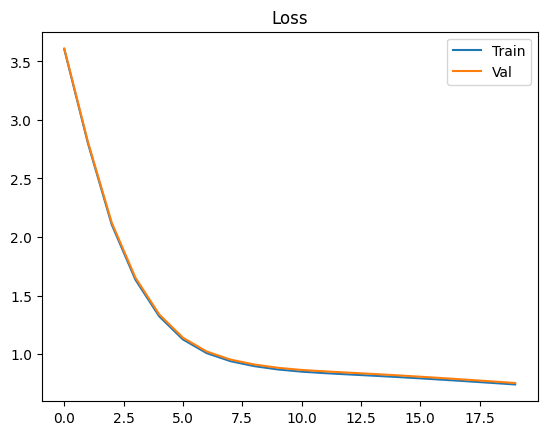

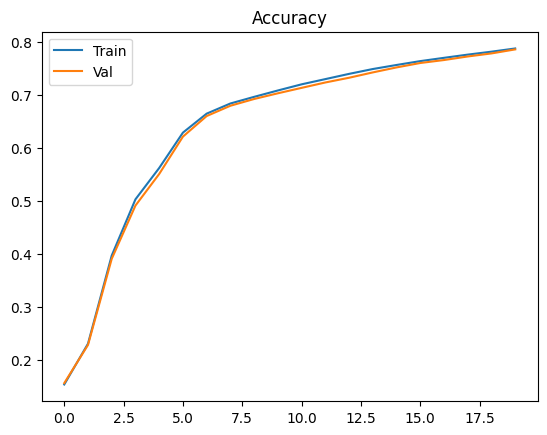

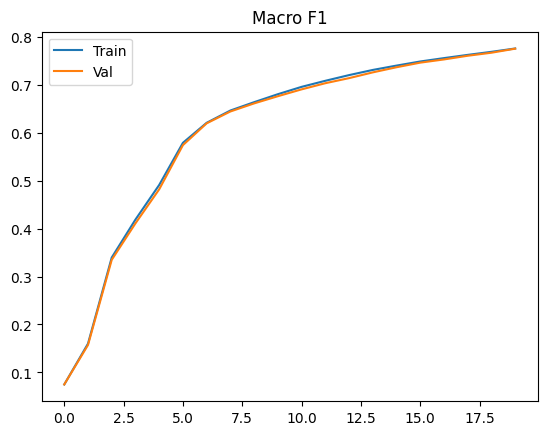

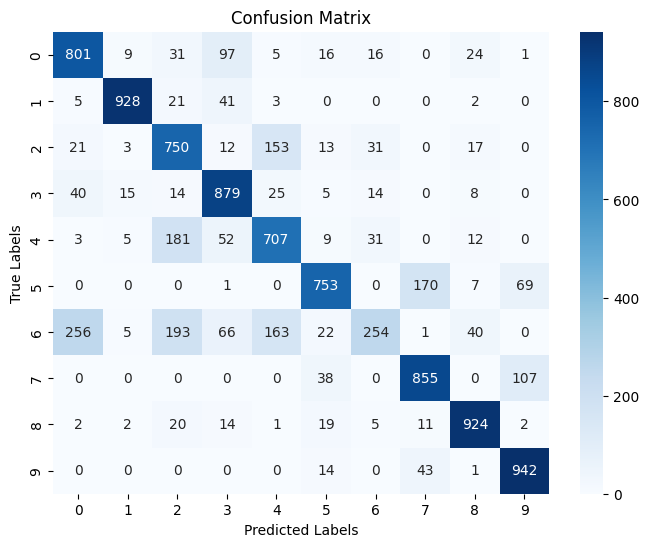

Accuracy:  0.7793  Loss:  0.761749877180236  Macro F1:  0.7667415032902222


Epoch 1/20: 100%|██████████| 750/750 [00:14<00:00, 50.62it/s]


Epoch:  1
Train
Accuracy:  0.8318125  Loss:  0.6829599923056539  Macro F1:  0.8297951717186581
Val
Accuracy:  0.8266666666666667  Loss:  0.6957510852276628  Macro F1:  0.8251329379297712


Epoch 2/20: 100%|██████████| 750/750 [00:15<00:00, 47.67it/s]


Epoch:  2
Train
Accuracy:  0.8442291666666667  Loss:  0.6507820152673747  Macro F1:  0.8425758153231403
Val
Accuracy:  0.83875  Loss:  0.6641711959209338  Macro F1:  0.8375445229376451


...

Epoch:  18
Train
Accuracy:  0.9161458333333333  Loss:  0.23844338730316955  Macro F1:  0.9140307766025513
Val
Accuracy:  0.8803333333333333  Loss:  0.3590150286388485  Macro F1:  0.8776416745286255


Epoch 19/20: 100%|██████████| 750/750 [00:15<00:00, 47.25it/s]


Epoch:  19
Train
Accuracy:  0.9256041666666667  Loss:  0.20769119682175474  Macro F1:  0.9249123446968841
Val
Accuracy:  0.8861666666666667  Loss:  0.33567988457712716  Macro F1:  0.8852146626745043


Epoch 20/20: 100%|██████████| 750/750 [00:15<00:00, 49.19it/s]


Epoch:  20
Train
Accuracy:  0.9289791666666667  Loss:  0.19427452207247858  Macro F1:  0.9290085495447606
Val
Accuracy:  0.8849166666666667  Loss:  0.3278147706772553  Macro F1:  0.8850885212085078


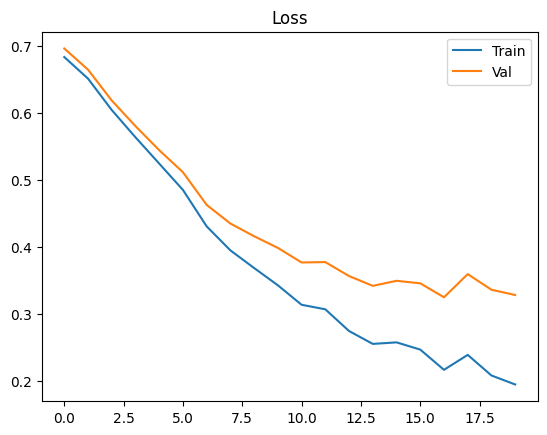

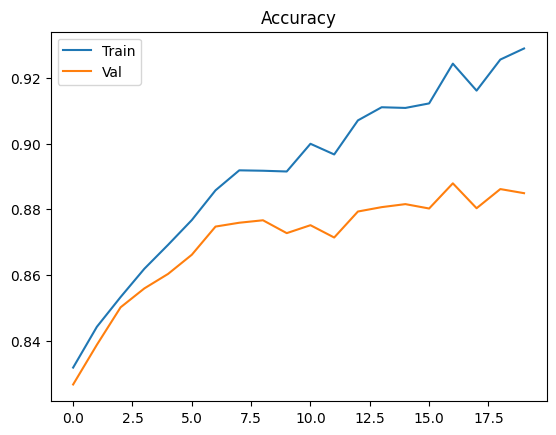

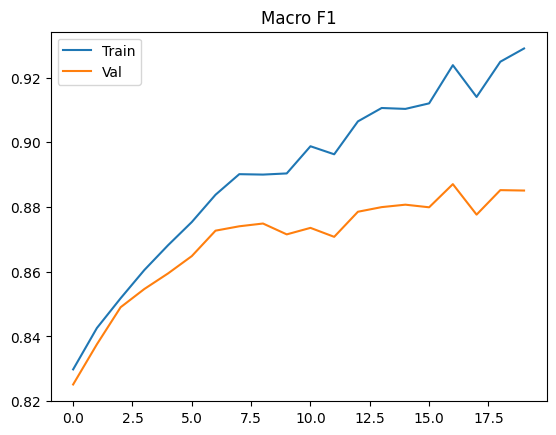

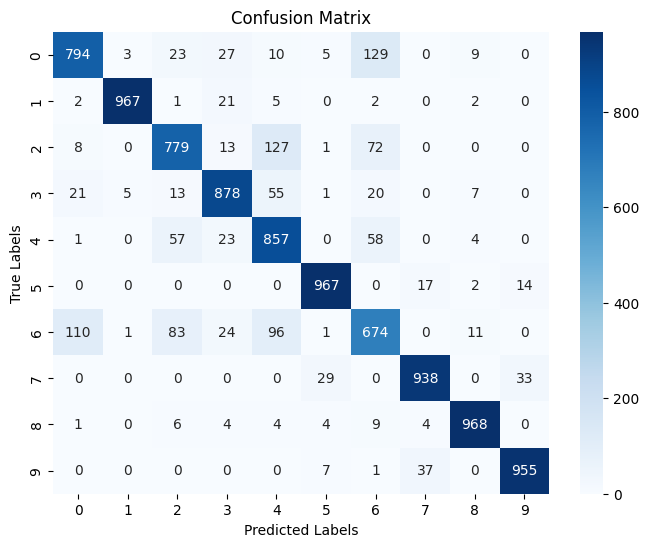

Accuracy:  0.8777  Loss:  0.3509115050913788  Macro F1:  0.877708047875522


Epoch 1/20: 100%|██████████| 750/750 [00:16<00:00, 45.26it/s]


Epoch:  1
Train
Accuracy:  0.9355208333333334  Loss:  0.1807147012873106  Macro F1:  0.9352591600738501
Val
Accuracy:  0.8908333333333334  Loss:  0.309842193712662  Macro F1:  0.8906631214654057


Epoch 2/20: 100%|██████████| 750/750 [00:16<00:00, 46.33it/s]


Epoch:  2
Train
Accuracy:  0.9415416666666667  Loss:  0.16760620738936485  Macro F1:  0.9410361900115889
Val
Accuracy:  0.8960833333333333  Loss:  0.29533933642578003  Macro F1:  0.8953630939066693


...

Epoch:  18
Train
Accuracy:  0.9599166666666666  Loss:  0.10956739000248543  Macro F1:  0.9601073365936073
Val
Accuracy:  0.8949166666666667  Loss:  0.31791557006668203  Macro F1:  0.8962198406930968


Epoch 19/20: 100%|██████████| 750/750 [00:18<00:00, 39.85it/s]


Epoch:  19
Train
Accuracy:  0.9598958333333333  Loss:  0.11097414988994606  Macro F1:  0.9596189666009082
Val
Accuracy:  0.893  Loss:  0.3295904429851295  Macro F1:  0.8927880696238552


Epoch 20/20: 100%|██████████| 750/750 [00:19<00:00, 39.08it/s]


Epoch:  20
Train
Accuracy:  0.9677291666666666  Loss:  0.08987312056619973  Macro F1:  0.967510990156385
Val
Accuracy:  0.8995833333333333  Loss:  0.31816787701084714  Macro F1:  0.8989330336716332


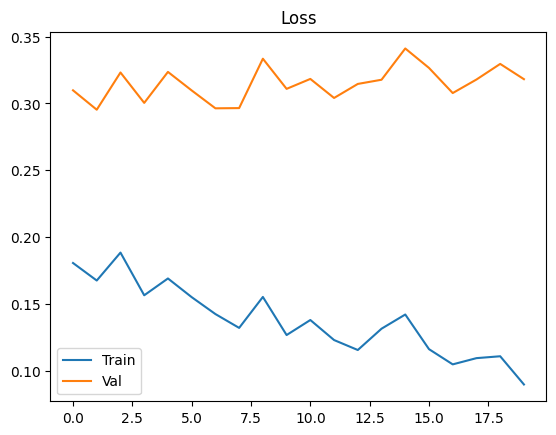

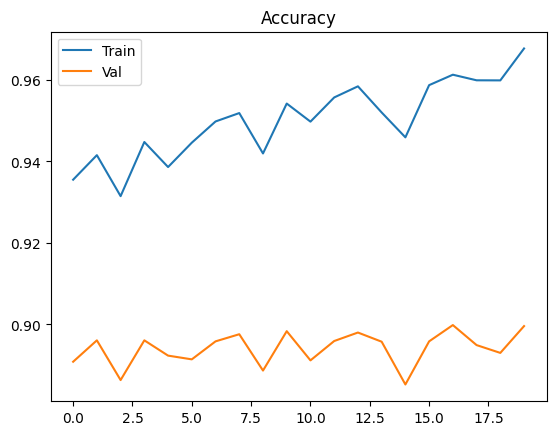

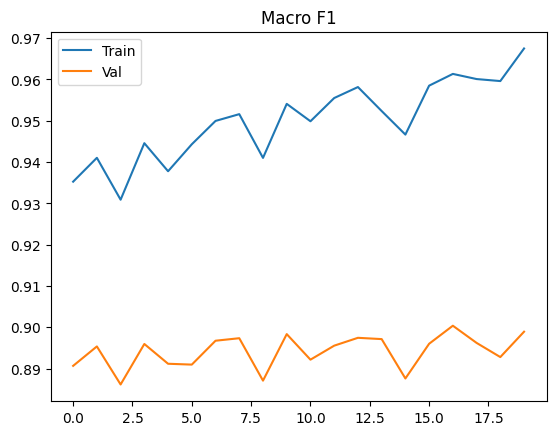

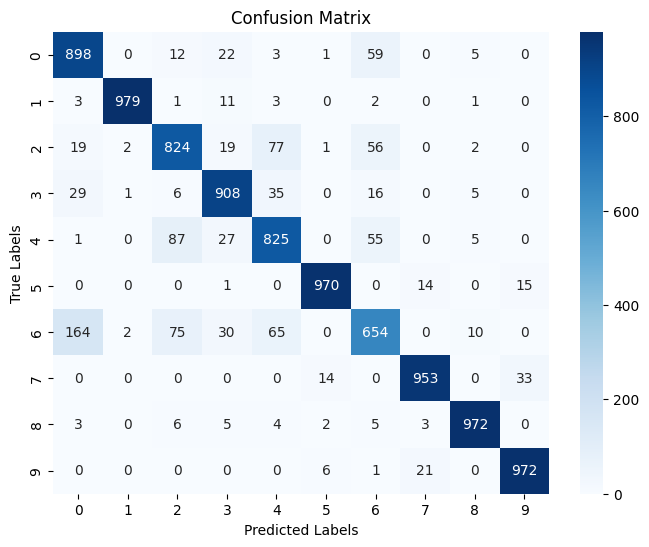

Accuracy:  0.8955  Loss:  0.3352310292146563  Macro F1:  0.8944909614105668


Epoch 1/40: 100%|██████████| 10/10 [00:00<00:00, 41.29it/s]


Epoch:  1
Train
Accuracy:  0.963625  Loss:  0.09902939222697181  Macro F1:  0.9633484627802777
Val
Accuracy:  0.89575  Loss:  0.3294950774234133  Macro F1:  0.8951784838915497


Epoch 2/40: 100%|██████████| 10/10 [00:00<00:00, 31.01it/s]


Epoch:  2
Train
Accuracy:  0.9650208333333333  Loss:  0.09483080060895877  Macro F1:  0.9649840316734855
Val
Accuracy:  0.89725  Loss:  0.322552658677689  Macro F1:  0.8975022145395842


...

Epoch:  38
Train
Accuracy:  0.9690416666666667  Loss:  0.08929638702163824  Macro F1:  0.9690098402436043
Val
Accuracy:  0.9011666666666667  Loss:  0.3115766077306622  Macro F1:  0.9011877466580342


Epoch 39/40: 100%|██████████| 10/10 [00:00<00:00, 41.88it/s]


Epoch:  39
Train
Accuracy:  0.9632916666666667  Loss:  0.10267273422020703  Macro F1:  0.9633080805679949
Val
Accuracy:  0.8968333333333334  Loss:  0.32725669108154665  Macro F1:  0.8970773843497317


Epoch 40/40: 100%|██████████| 10/10 [00:00<00:00, 41.21it/s]


Epoch:  40
Train
Accuracy:  0.9648541666666667  Loss:  0.098385121367162  Macro F1:  0.9647685704407554
Val
Accuracy:  0.8949166666666667  Loss:  0.3255606470126793  Macro F1:  0.8947944002699041


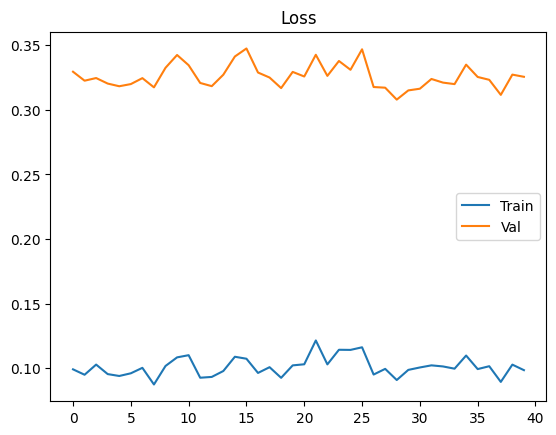

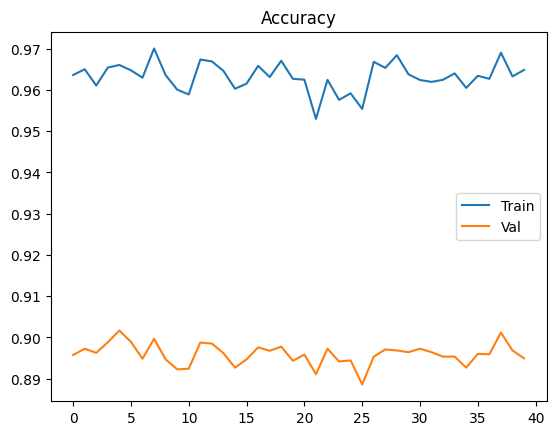

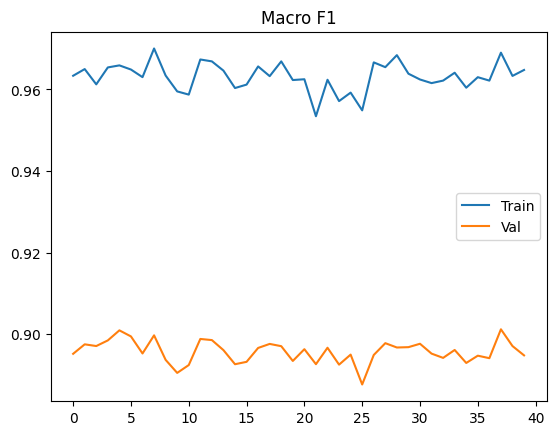

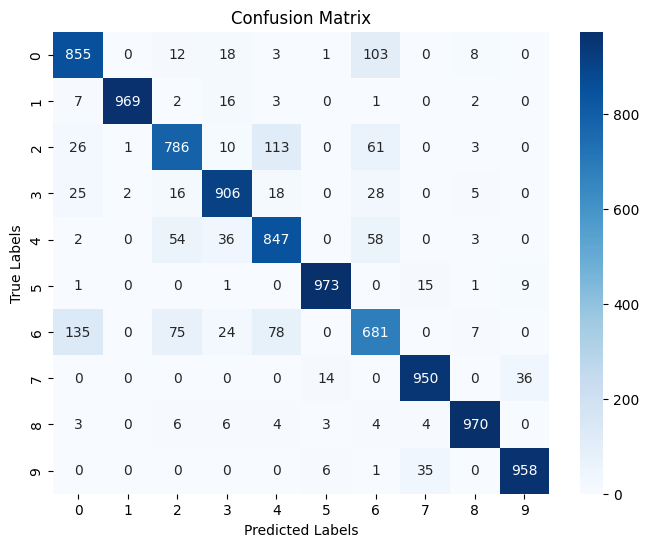

Accuracy:  0.8895  Loss:  0.34515589581454587  Macro F1:  0.8892092078163566


(0.34515589581454587, 0.8895, 0.8892092078163566)

In [6]:
batch_size=64
np.random.seed(42)

model=FNN().MODEL1()

eval=Evaluation()
model1=eval.trainWhole(model, 20, x_trn, y_trn, x_val, y_val) 
eval.predict(model1, x_test, y_test, cm=True)  

model2=eval.trainSeq(model, 20, batch_size, x_trn, y_trn, x_val, y_val)
eval.predict(model2, x_test, y_test, cm=True)

model3=eval.trainRan(model, 20, batch_size, x_trn, y_trn, x_val, y_val)
eval.predict(model3, x_test, y_test, cm=True)

model4=eval.trainMoreRan(model, 40, batch_size, x_trn, y_trn, x_val, y_val, batch_itr=10)
eval.predict(model4, x_test, y_test, cm=True)


# 27 Different Models

Model 1. 1
Sequential alpha:  0.01 decay: 0.99 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:11<00:00, 31.82it/s]


Epoch:  1
Train
Accuracy:  0.8432291666666667  Loss:  0.4653905873811779  Macro F1:  0.8391928892245015
Val
Accuracy:  0.8364166666666667  Loss:  0.47930243682682305  Macro F1:  0.8328754586460114


Epoch 2/20: 100%|██████████| 375/375 [00:10<00:00, 36.96it/s]


Epoch:  2
Train
Accuracy:  0.8485625  Loss:  0.45397526095413965  Macro F1:  0.8452129939853507
Val
Accuracy:  0.8403333333333334  Loss:  0.46814261407309776  Macro F1:  0.8375702424875169


...

Epoch:  18
Train
Accuracy:  0.8486458333333333  Loss:  0.4539743861699996  Macro F1:  0.8454552954290259
Val
Accuracy:  0.8415  Loss:  0.46798156495853244  Macro F1:  0.8387972565783913


Epoch 19/20: 100%|██████████| 375/375 [00:10<00:00, 36.71it/s]


Epoch:  19
Train
Accuracy:  0.8484375  Loss:  0.4556918411833808  Macro F1:  0.8453669914646273
Val
Accuracy:  0.8408333333333333  Loss:  0.4697438186277898  Macro F1:  0.8382397902028819


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 34.68it/s]


Epoch:  20
Train
Accuracy:  0.8480625  Loss:  0.4546877320189311  Macro F1:  0.8447204076083512
Val
Accuracy:  0.8405833333333333  Loss:  0.46874716782843967  Macro F1:  0.8378793642610225


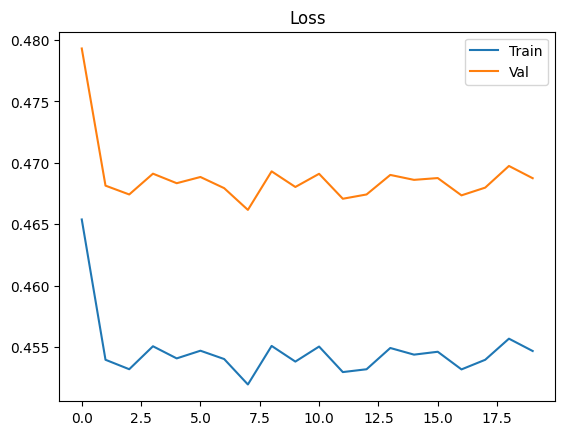

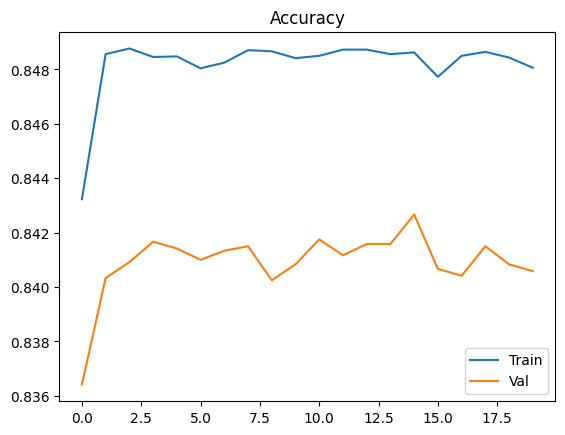

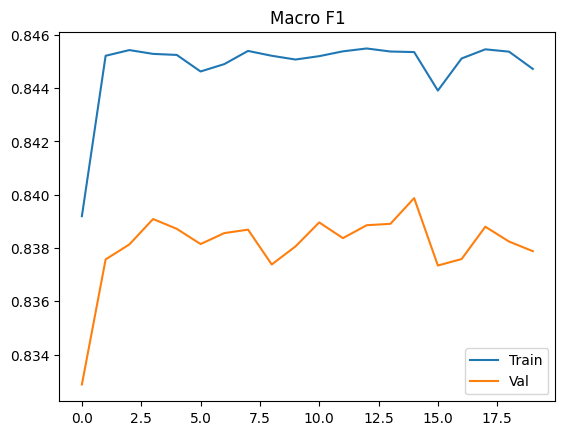

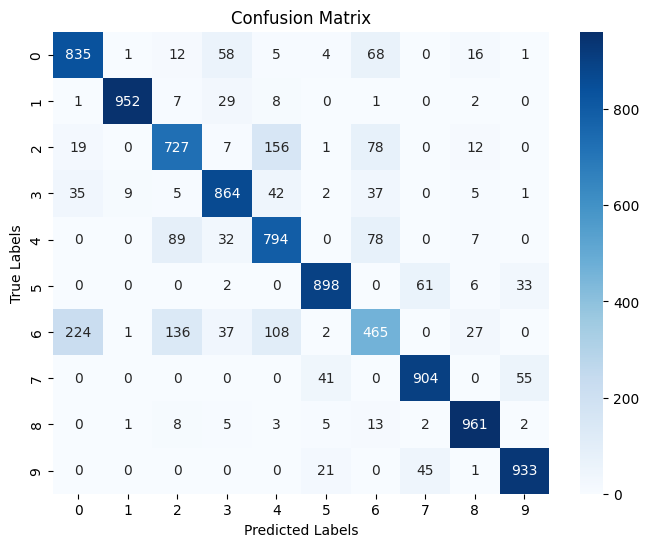

Accuracy:  0.8333  Loss:  0.4891681664553851  Macro F1:  0.8300259513735812
Random alpha:  0.01 decay: 0.99 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:10<00:00, 34.38it/s]


Epoch:  1
Train
Accuracy:  0.8476458333333333  Loss:  0.45374940502100514  Macro F1:  0.8444382763577531
Val
Accuracy:  0.8410833333333333  Loss:  0.4679856496198035  Macro F1:  0.838461957699011


Epoch 2/20: 100%|██████████| 375/375 [00:12<00:00, 30.53it/s]


Epoch:  2
Train
Accuracy:  0.848875  Loss:  0.45384822719648255  Macro F1:  0.8455452533273737
Val
Accuracy:  0.8423333333333334  Loss:  0.467952822941644  Macro F1:  0.839445406689434


...

Epoch:  18
Train
Accuracy:  0.8479583333333334  Loss:  0.4538540383474584  Macro F1:  0.8446076203891625
Val
Accuracy:  0.8399166666666666  Loss:  0.4683596288265382  Macro F1:  0.8370433951591135


Epoch 19/20: 100%|██████████| 375/375 [00:11<00:00, 33.13it/s]


Epoch:  19
Train
Accuracy:  0.8478541666666667  Loss:  0.45448413516535874  Macro F1:  0.8440951636749003
Val
Accuracy:  0.84025  Loss:  0.4689305428435401  Macro F1:  0.8370859747820918


Epoch 20/20: 100%|██████████| 375/375 [00:11<00:00, 33.66it/s]


Epoch:  20
Train
Accuracy:  0.8484166666666667  Loss:  0.45380711816860486  Macro F1:  0.845058378062518
Val
Accuracy:  0.84175  Loss:  0.46812419077052037  Macro F1:  0.8389259411479577


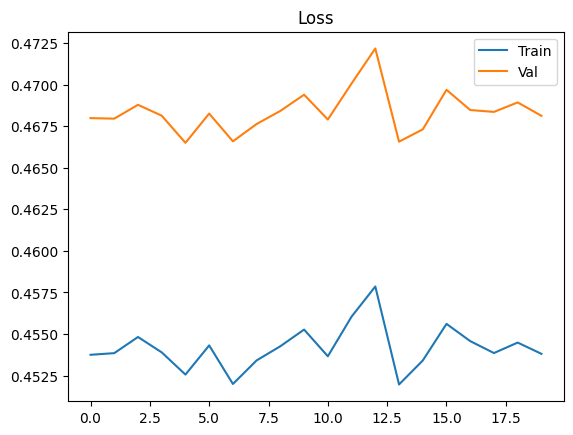

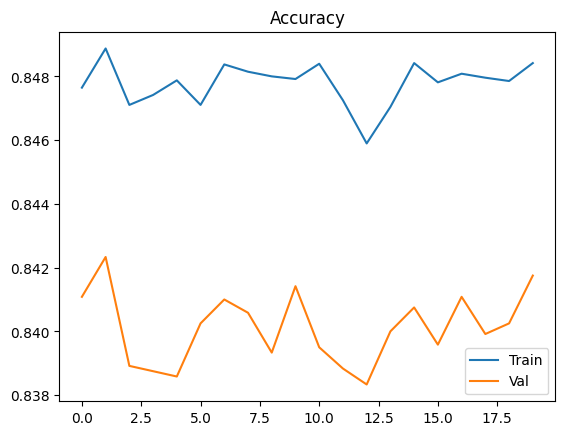

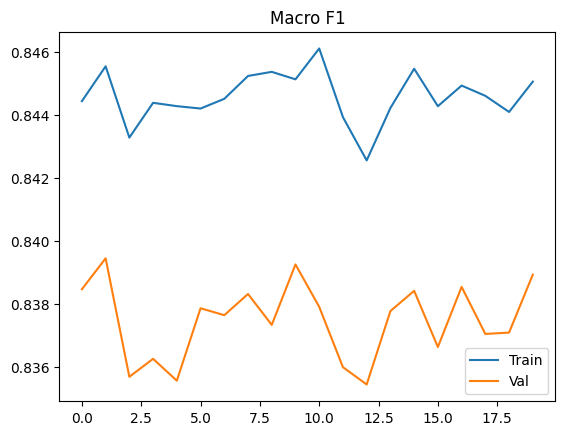

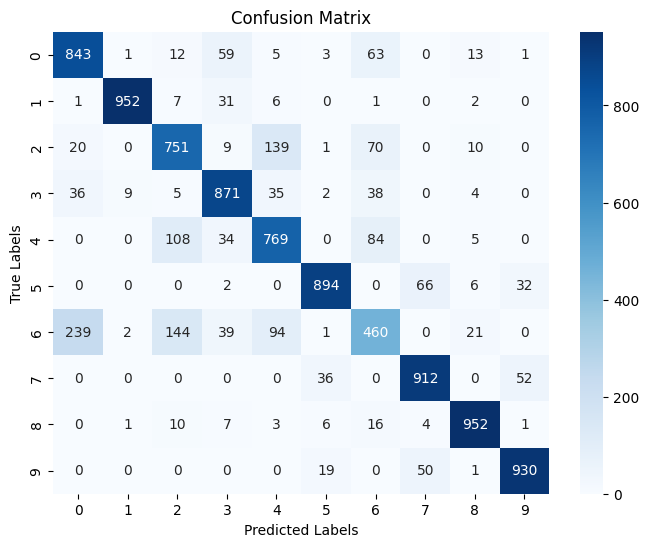

Accuracy:  0.8334  Loss:  0.48802108213593043  Macro F1:  0.8301472361822475
More Random alpha:  0.01 decay: 0.99 dropout: 0.5 optimizer: ADAM


Epoch 1/50: 100%|██████████| 30/30 [00:00<00:00, 34.33it/s]


Epoch:  1
Train
Accuracy:  0.8473958333333333  Loss:  0.45619542476058406  Macro F1:  0.844062952576534
Val
Accuracy:  0.841  Loss:  0.4702350428131384  Macro F1:  0.8382576261628959


Epoch 2/50: 100%|██████████| 30/30 [00:00<00:00, 33.31it/s]


Epoch:  2
Train
Accuracy:  0.84725  Loss:  0.45681110389636936  Macro F1:  0.8434184177151856
Val
Accuracy:  0.8396666666666667  Loss:  0.47116345263301784  Macro F1:  0.8363924034138346


...

Epoch:  48
Train
Accuracy:  0.8484583333333333  Loss:  0.45315303879163155  Macro F1:  0.8457355773052779
Val
Accuracy:  0.8410833333333333  Loss:  0.46716928856696394  Macro F1:  0.8389877658783851


Epoch 49/50: 100%|██████████| 30/30 [00:00<00:00, 33.33it/s]


Epoch:  49
Train
Accuracy:  0.8491041666666667  Loss:  0.455166407060996  Macro F1:  0.845955279020186
Val
Accuracy:  0.8403333333333334  Loss:  0.46948669755016414  Macro F1:  0.8376917812754474


Epoch 50/50: 100%|██████████| 30/30 [00:00<00:00, 31.13it/s]


Epoch:  50
Train
Accuracy:  0.8478333333333333  Loss:  0.4531806886443484  Macro F1:  0.8444863468906678
Val
Accuracy:  0.8399166666666666  Loss:  0.46718603891228316  Macro F1:  0.8371360352273294


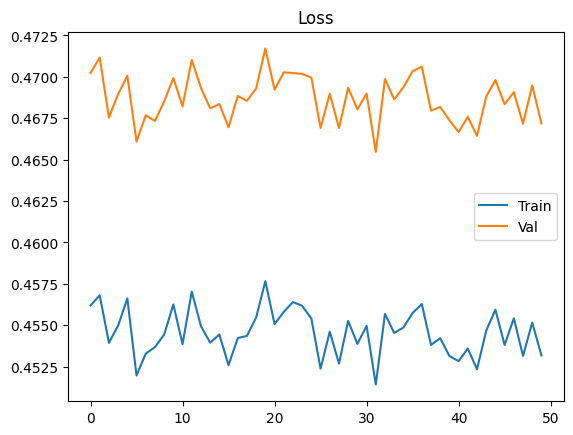

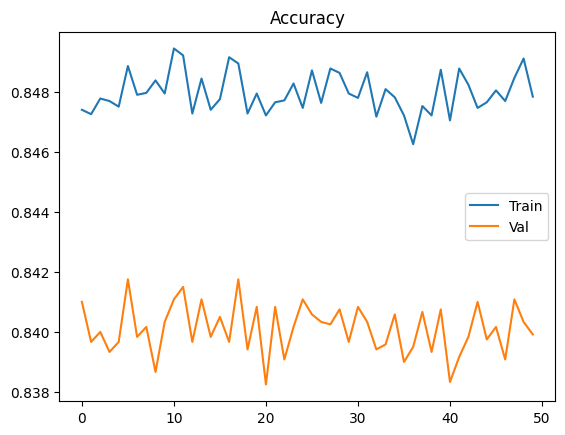

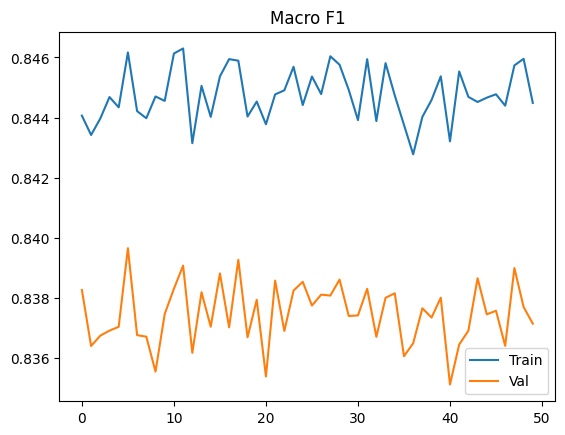

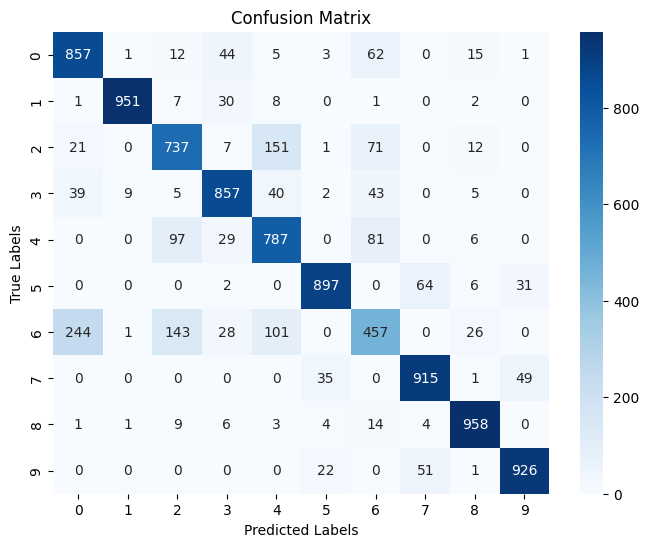

Accuracy:  0.8342  Loss:  0.487132446064487  Macro F1:  0.8309165385706564
Model 1. 2
Sequential alpha:  0.001 decay: 0.999 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:10<00:00, 36.03it/s]


Epoch:  1
Train
Accuracy:  0.844625  Loss:  0.5493181052406892  Macro F1:  0.841299860846847
Val
Accuracy:  0.8390833333333333  Loss:  0.562410482307429  Macro F1:  0.8362847231295645


Epoch 2/20: 100%|██████████| 375/375 [00:10<00:00, 36.41it/s]


Epoch:  2
Train
Accuracy:  0.8620833333333333  Loss:  0.44661921222362394  Macro F1:  0.8589245361679773
Val
Accuracy:  0.8565833333333334  Loss:  0.46547159706423236  Macro F1:  0.8536626433439917


...

Epoch:  18
Train
Accuracy:  0.8943333333333333  Loss:  0.32355781416776735  Macro F1:  0.8934702728293591
Val
Accuracy:  0.88075  Loss:  0.36176907181096996  Macro F1:  0.8801376425951292


Epoch 19/20: 100%|██████████| 375/375 [00:10<00:00, 36.85it/s]


Epoch:  19
Train
Accuracy:  0.8943333333333333  Loss:  0.32408359241927404  Macro F1:  0.8935253915393286
Val
Accuracy:  0.8809166666666667  Loss:  0.36232516962404027  Macro F1:  0.8804250488979355


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 35.77it/s]


Epoch:  20
Train
Accuracy:  0.894125  Loss:  0.3241635296815709  Macro F1:  0.8931712252352128
Val
Accuracy:  0.8798333333333334  Loss:  0.3625870194039572  Macro F1:  0.8791707843927989


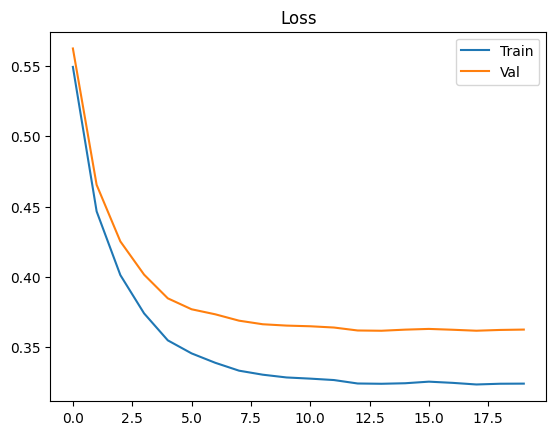

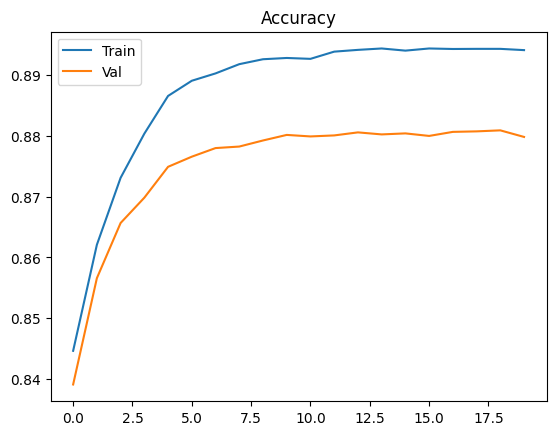

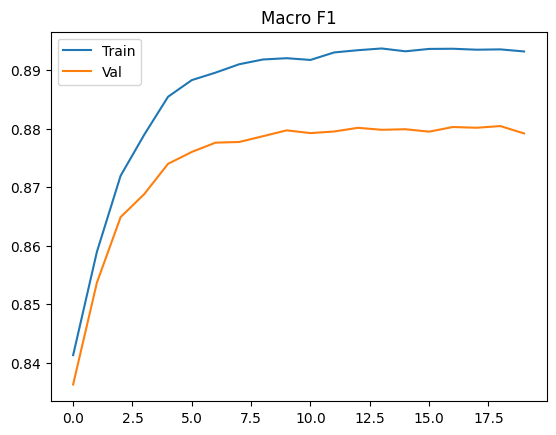

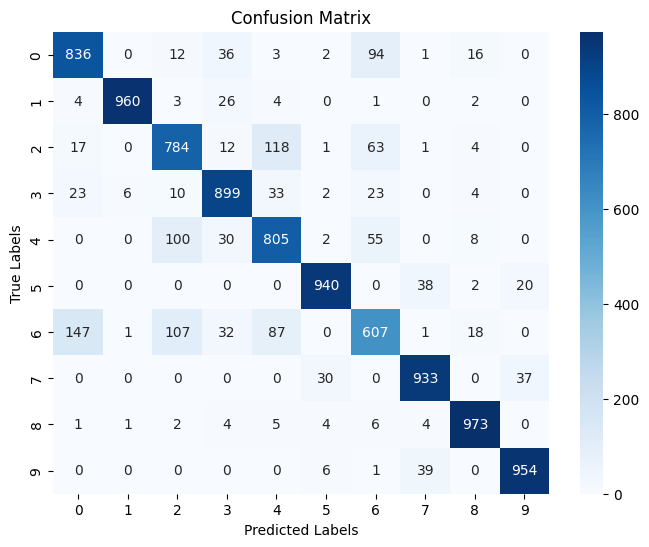

Accuracy:  0.8691  Loss:  0.3910213958517855  Macro F1:  0.8678657781452641
Random alpha:  0.001 decay: 0.999 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:10<00:00, 34.26it/s]


Epoch:  1
Train
Accuracy:  0.8944166666666666  Loss:  0.3255495690361435  Macro F1:  0.8937170845419832
Val
Accuracy:  0.8801666666666667  Loss:  0.36382432708010093  Macro F1:  0.8797722712835692


Epoch 2/20: 100%|██████████| 375/375 [00:10<00:00, 34.63it/s]


Epoch:  2
Train
Accuracy:  0.8944583333333334  Loss:  0.3234459083884915  Macro F1:  0.8934567404003193
Val
Accuracy:  0.8810833333333333  Loss:  0.3613501170698339  Macro F1:  0.8804368270431386


...

Epoch:  18
Train
Accuracy:  0.8945833333333333  Loss:  0.3235815291814319  Macro F1:  0.893886222161826
Val
Accuracy:  0.8803333333333333  Loss:  0.36148688579106836  Macro F1:  0.8799791897902921


Epoch 19/20: 100%|██████████| 375/375 [00:10<00:00, 35.10it/s]


Epoch:  19
Train
Accuracy:  0.8943333333333333  Loss:  0.32267456424728114  Macro F1:  0.8934940264983469
Val
Accuracy:  0.8818333333333334  Loss:  0.3605273853243585  Macro F1:  0.8812931951028473


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 34.83it/s]


Epoch:  20
Train
Accuracy:  0.89425  Loss:  0.32451559116122797  Macro F1:  0.8929521370261682
Val
Accuracy:  0.8808333333333334  Loss:  0.3625619304808582  Macro F1:  0.879772760745644


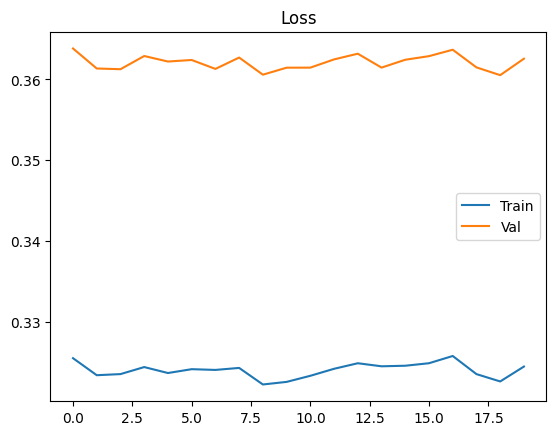

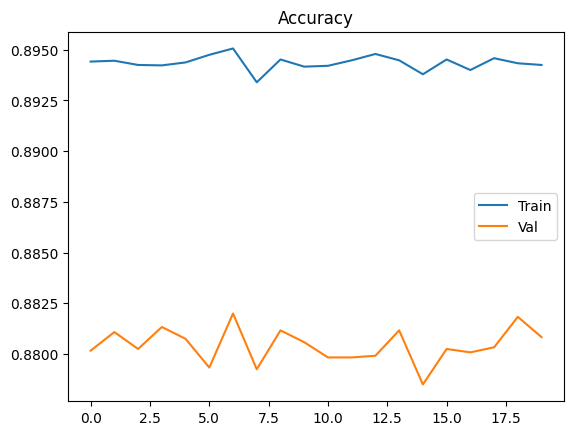

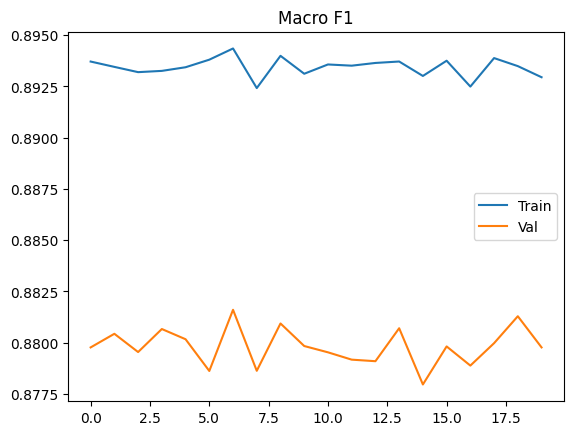

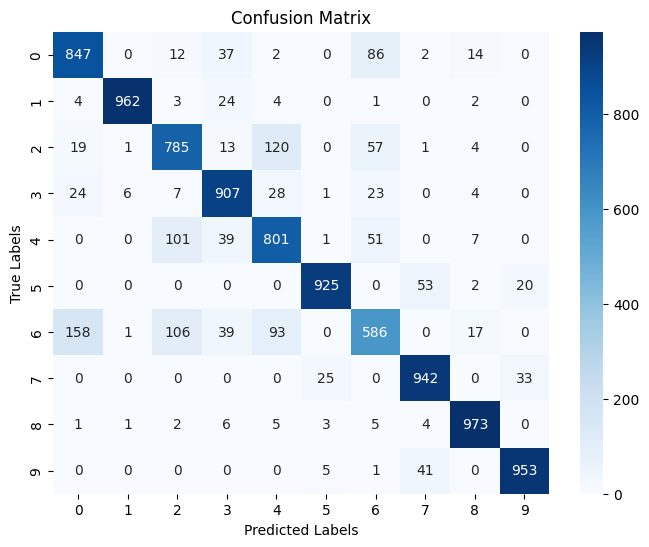

Accuracy:  0.8681  Loss:  0.39178576515542957  Macro F1:  0.8664481777350874
More Random alpha:  0.001 decay: 0.999 dropout: 0.5 optimizer: ADAM


Epoch 1/50: 100%|██████████| 30/30 [00:00<00:00, 35.82it/s]


Epoch:  1
Train
Accuracy:  0.8941875  Loss:  0.32301786830859225  Macro F1:  0.8930709231311298
Val
Accuracy:  0.88075  Loss:  0.3618184518206936  Macro F1:  0.8799801611745262


Epoch 2/50: 100%|██████████| 30/30 [00:00<00:00, 31.99it/s]


Epoch:  2
Train
Accuracy:  0.8934375  Loss:  0.32595487590982214  Macro F1:  0.8920899140304206
Val
Accuracy:  0.8798333333333334  Loss:  0.3640327484421268  Macro F1:  0.8787402408522876


...

Epoch:  48
Train
Accuracy:  0.8946041666666666  Loss:  0.3242969064225516  Macro F1:  0.893504200056706
Val
Accuracy:  0.8795833333333334  Loss:  0.3620630814236357  Macro F1:  0.878759701034082


Epoch 49/50: 100%|██████████| 30/30 [00:01<00:00, 21.65it/s]


Epoch:  49
Train
Accuracy:  0.8941458333333333  Loss:  0.32393559988745646  Macro F1:  0.8932397967217753
Val
Accuracy:  0.87975  Loss:  0.3622710546274356  Macro F1:  0.8791528021136006


Epoch 50/50: 100%|██████████| 30/30 [00:00<00:00, 33.90it/s]


Epoch:  50
Train
Accuracy:  0.8943541666666667  Loss:  0.32437067871904157  Macro F1:  0.8932335992747451
Val
Accuracy:  0.8800833333333333  Loss:  0.3625119027031859  Macro F1:  0.8793088682900898


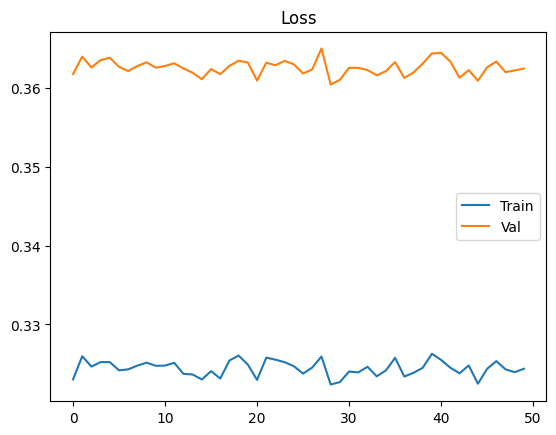

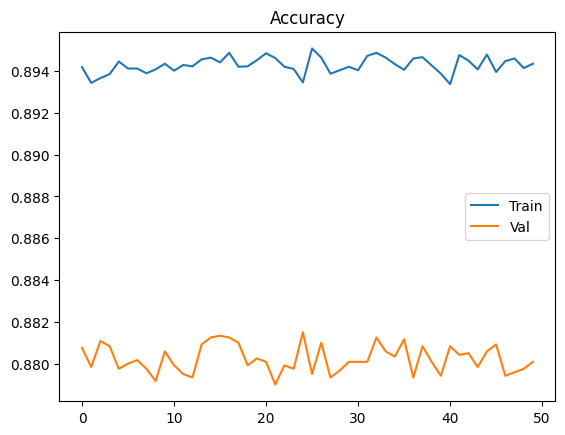

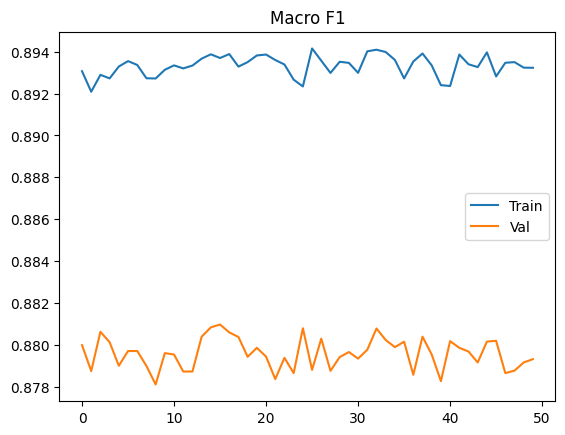

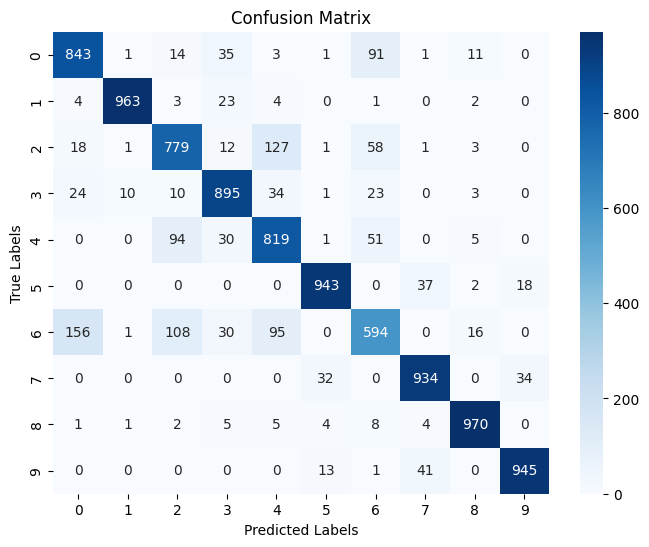

Accuracy:  0.8685  Loss:  0.3903679390654342  Macro F1:  0.8671446090453937
Model 1. 3
Sequential alpha:  0.00078125 decay: 0.9999 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:10<00:00, 35.83it/s]


Epoch:  1
Train
Accuracy:  0.8417916666666667  Loss:  0.5658885055721604  Macro F1:  0.839160922717584
Val
Accuracy:  0.8381666666666666  Loss:  0.5785268520846867  Macro F1:  0.8359652032766597


Epoch 2/20: 100%|██████████| 375/375 [00:10<00:00, 36.66it/s]


Epoch:  2
Train
Accuracy:  0.8632291666666667  Loss:  0.4407200442273337  Macro F1:  0.8622762842686151
Val
Accuracy:  0.8560833333333333  Loss:  0.4579844542337008  Macro F1:  0.8555963000878986


...

Epoch:  18
Train
Accuracy:  0.9232916666666666  Loss:  0.21670937676057728  Macro F1:  0.9227036218033975
Val
Accuracy:  0.892  Loss:  0.31151661301349  Macro F1:  0.8913568991015014


Epoch 19/20: 100%|██████████| 375/375 [00:11<00:00, 33.19it/s]


Epoch:  19
Train
Accuracy:  0.9260625  Loss:  0.2106049627668581  Macro F1:  0.9256027512894981
Val
Accuracy:  0.8940833333333333  Loss:  0.3084975198182045  Macro F1:  0.893666025225708


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 36.50it/s]


Epoch:  20
Train
Accuracy:  0.9256666666666666  Loss:  0.20823058300636918  Macro F1:  0.9251517963119088
Val
Accuracy:  0.8920833333333333  Loss:  0.3092028398985997  Macro F1:  0.8917010867749248


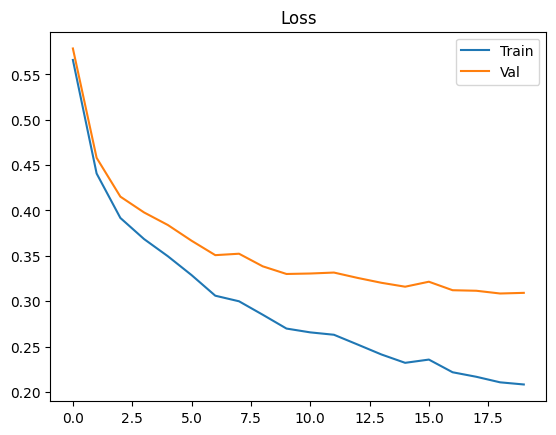

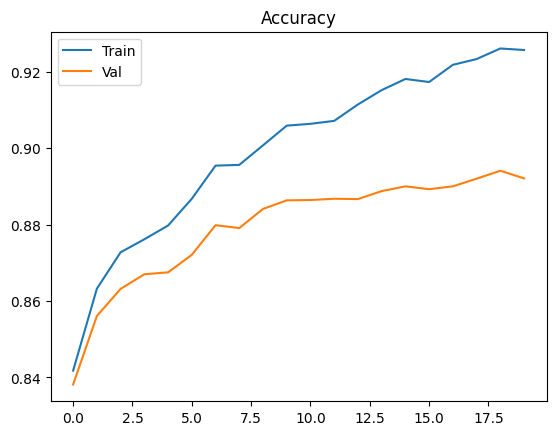

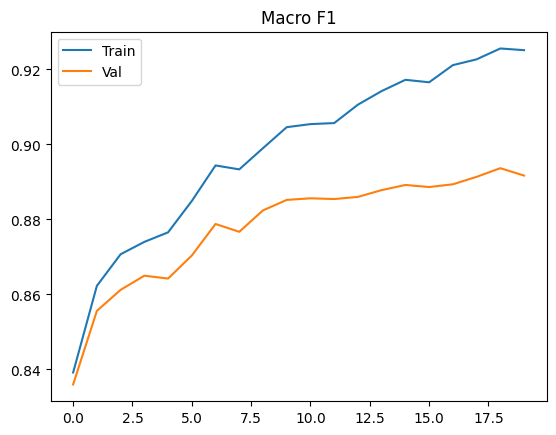

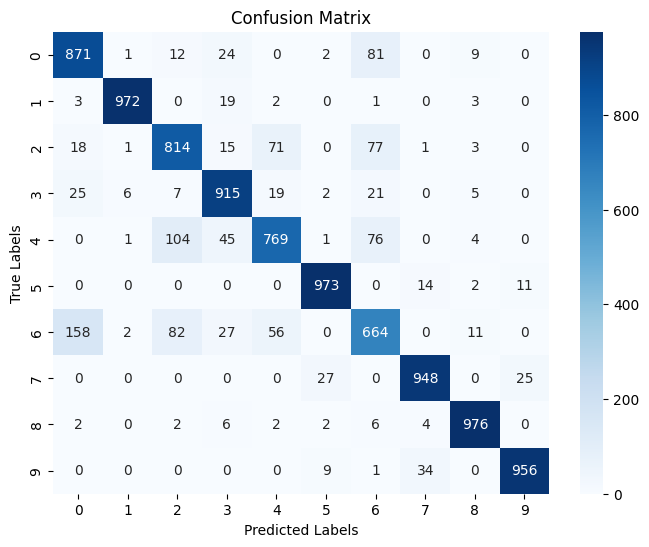

Accuracy:  0.8858  Loss:  0.33637900677791943  Macro F1:  0.8849785562155056
Random alpha:  0.00078125 decay: 0.9999 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:11<00:00, 32.64it/s]


Epoch:  1
Train
Accuracy:  0.9289375  Loss:  0.2029141694234481  Macro F1:  0.9285998103213657
Val
Accuracy:  0.8949166666666667  Loss:  0.30500042799792443  Macro F1:  0.894740435426392


Epoch 2/20: 100%|██████████| 375/375 [00:10<00:00, 34.12it/s]


Epoch:  2
Train
Accuracy:  0.930875  Loss:  0.20077276972863417  Macro F1:  0.9304718512143936
Val
Accuracy:  0.8930833333333333  Loss:  0.3062495522909106  Macro F1:  0.8925771055201013


...

Epoch:  18
Train
Accuracy:  0.9490833333333333  Loss:  0.1486586253942244  Macro F1:  0.9488203594397735
Val
Accuracy:  0.9001666666666667  Loss:  0.2960974319977514  Macro F1:  0.899694384654174


Epoch 19/20: 100%|██████████| 375/375 [00:11<00:00, 32.01it/s]


Epoch:  19
Train
Accuracy:  0.9499791666666667  Loss:  0.14462798157910478  Macro F1:  0.9498446959317789
Val
Accuracy:  0.9009166666666667  Loss:  0.2932779159411636  Macro F1:  0.900777150256463


Epoch 20/20: 100%|██████████| 375/375 [00:11<00:00, 33.97it/s]


Epoch:  20
Train
Accuracy:  0.9482916666666666  Loss:  0.14761994825389704  Macro F1:  0.9478182621125028
Val
Accuracy:  0.8993333333333333  Loss:  0.2967130446382591  Macro F1:  0.89841809889512


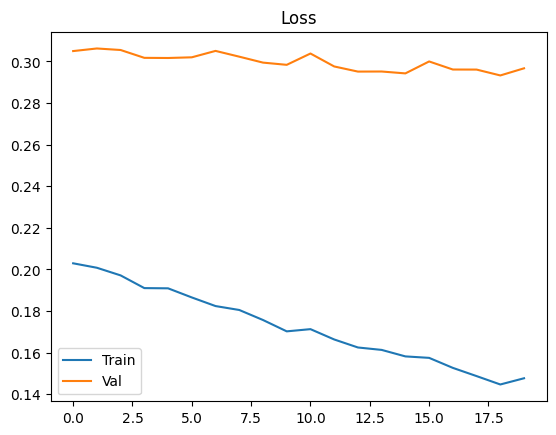

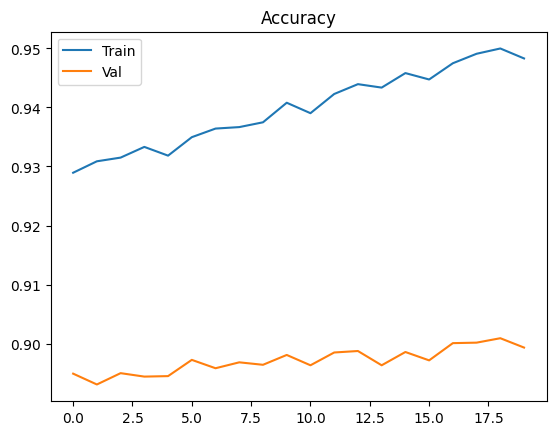

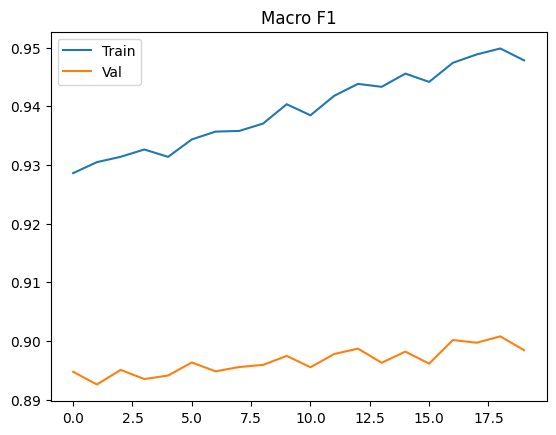

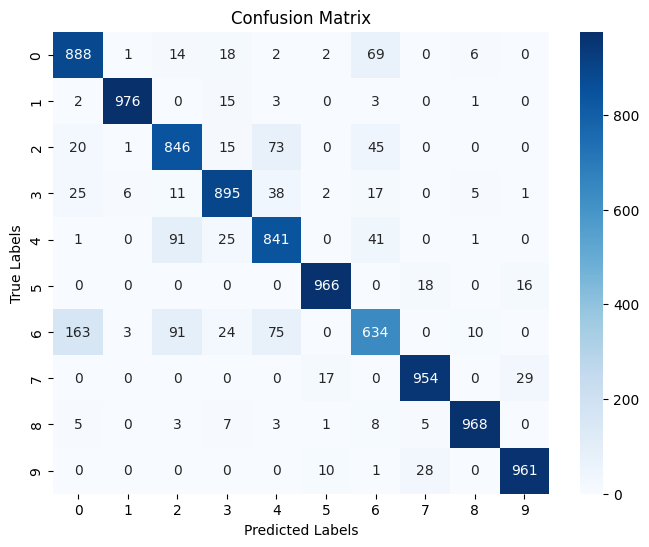

Accuracy:  0.8929  Loss:  0.3192533385589907  Macro F1:  0.8917514101878238
More Random alpha:  0.00078125 decay: 0.9999 dropout: 0.5 optimizer: ADAM


Epoch 1/50: 100%|██████████| 30/30 [00:00<00:00, 35.00it/s]


Epoch:  1
Train
Accuracy:  0.9500625  Loss:  0.14722245515379778  Macro F1:  0.9497853407782646
Val
Accuracy:  0.8994166666666666  Loss:  0.2961165031745935  Macro F1:  0.8989099253196358


Epoch 2/50: 100%|██████████| 30/30 [00:00<00:00, 35.04it/s]


Epoch:  2
Train
Accuracy:  0.9510208333333333  Loss:  0.14335025667936516  Macro F1:  0.9508460061396942
Val
Accuracy:  0.90025  Loss:  0.29418084106001974  Macro F1:  0.9000614317266736


...

Epoch:  48
Train
Accuracy:  0.9535208333333334  Loss:  0.13665926853876562  Macro F1:  0.9531258085378351
Val
Accuracy:  0.9016666666666666  Loss:  0.2972350370709188  Macro F1:  0.900799512757229


Epoch 49/50: 100%|██████████| 30/30 [00:00<00:00, 35.52it/s]


Epoch:  49
Train
Accuracy:  0.9533958333333333  Loss:  0.13624809438054652  Macro F1:  0.9532208949930269
Val
Accuracy:  0.901  Loss:  0.2943126141838981  Macro F1:  0.900544510084005


Epoch 50/50: 100%|██████████| 30/30 [00:00<00:00, 35.59it/s]


Epoch:  50
Train
Accuracy:  0.953375  Loss:  0.1360858447596653  Macro F1:  0.9531228913017575
Val
Accuracy:  0.90025  Loss:  0.2942944074074814  Macro F1:  0.8997361458200046


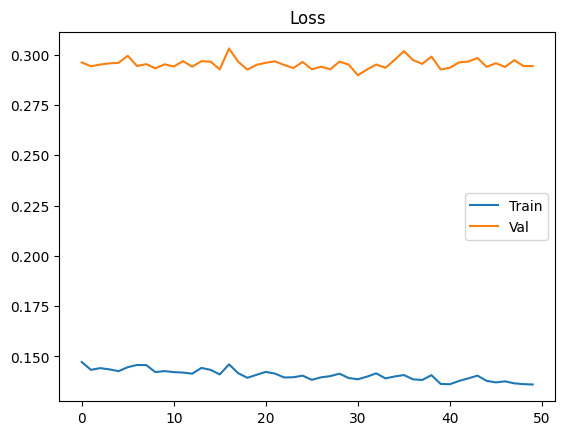

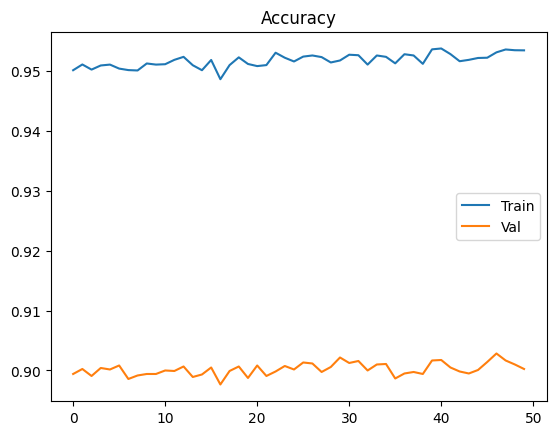

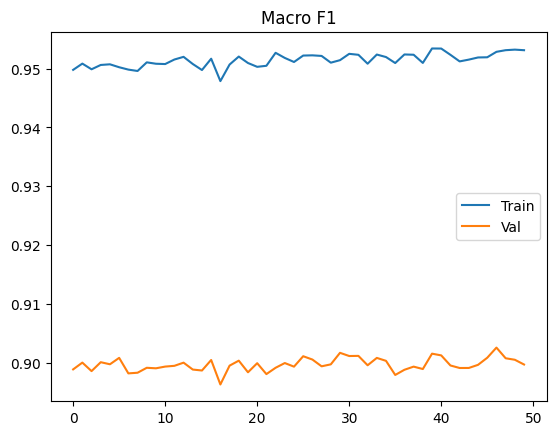

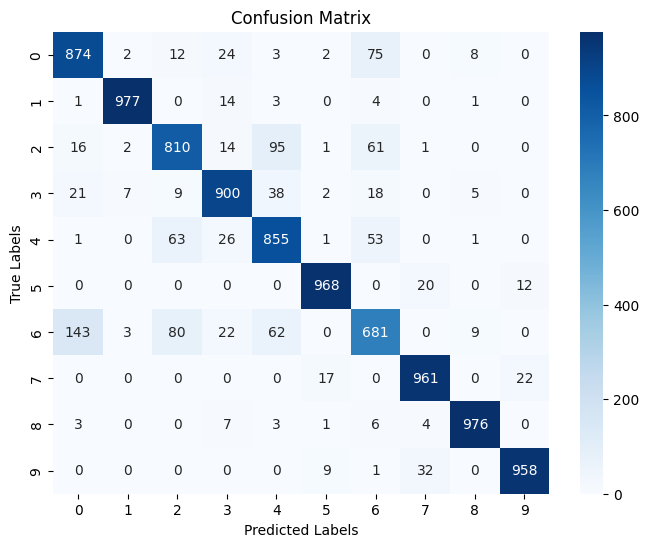

Accuracy:  0.896  Loss:  0.31298967760980134  Macro F1:  0.8953413467237024
Model 2. 1
Sequential alpha:  0.01 decay: 0.99 dropout: 0.5 optimizer: YOGI


Epoch 1/20: 100%|██████████| 375/375 [00:10<00:00, 37.42it/s]


Epoch:  1
Train
Accuracy:  0.856  Loss:  0.44114837306296184  Macro F1:  0.8537955687881409
Val
Accuracy:  0.8491666666666666  Loss:  0.4540550012920549  Macro F1:  0.8475630208414836


Epoch 2/20: 100%|██████████| 375/375 [00:11<00:00, 33.83it/s]


Epoch:  2
Train
Accuracy:  0.8575416666666666  Loss:  0.432337855364773  Macro F1:  0.8557314352185446
Val
Accuracy:  0.8510833333333333  Loss:  0.44568996907407465  Macro F1:  0.8497307219820236


...

Epoch:  18
Train
Accuracy:  0.8574375  Loss:  0.43303017296602203  Macro F1:  0.8553576629379513
Val
Accuracy:  0.85075  Loss:  0.4464462167957753  Macro F1:  0.8491847467652557


Epoch 19/20: 100%|██████████| 375/375 [00:10<00:00, 35.38it/s]


Epoch:  19
Train
Accuracy:  0.857  Loss:  0.4309556077846103  Macro F1:  0.8548369343337056
Val
Accuracy:  0.8503333333333334  Loss:  0.4445430032208907  Macro F1:  0.8486911689397256


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 35.71it/s]


Epoch:  20
Train
Accuracy:  0.8576041666666666  Loss:  0.4325607278095869  Macro F1:  0.8554668174069595
Val
Accuracy:  0.8510833333333333  Loss:  0.445872443305588  Macro F1:  0.8494158220765312


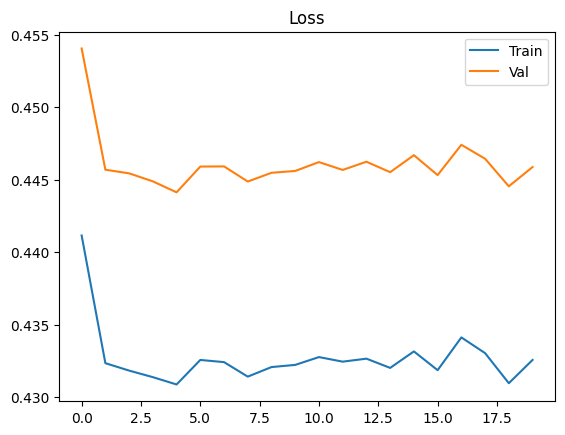

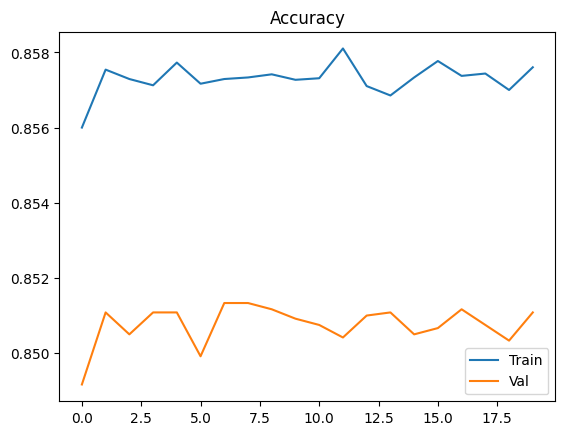

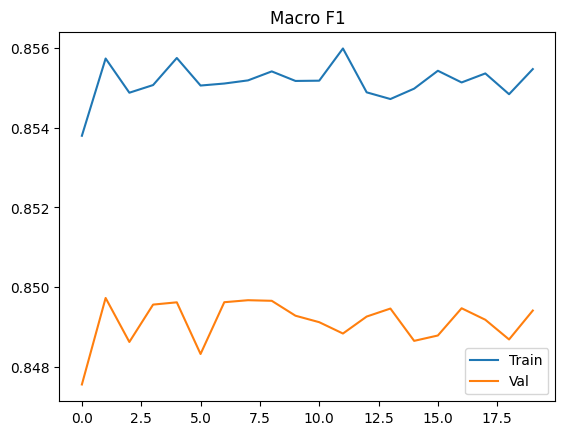

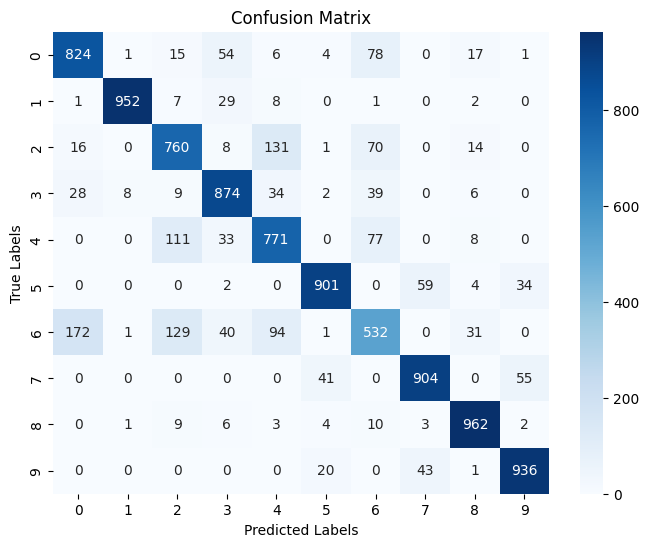

Accuracy:  0.8416  Loss:  0.4699602122665134  Macro F1:  0.8395683760124333
Random alpha:  0.01 decay: 0.99 dropout: 0.5 optimizer: YOGI


Epoch 1/20: 100%|██████████| 375/375 [00:11<00:00, 32.91it/s]


Epoch:  1
Train
Accuracy:  0.8574791666666667  Loss:  0.43409367726133613  Macro F1:  0.8558915036027065
Val
Accuracy:  0.851  Loss:  0.44779249258516046  Macro F1:  0.849915632297608


Epoch 2/20: 100%|██████████| 375/375 [00:11<00:00, 33.34it/s]


Epoch:  2
Train
Accuracy:  0.8576875  Loss:  0.43149607476003926  Macro F1:  0.856334368244721
Val
Accuracy:  0.8499166666666667  Loss:  0.44449943721544133  Macro F1:  0.8491721400039097


...

Epoch:  18
Train
Accuracy:  0.85775  Loss:  0.43089963904050266  Macro F1:  0.8556349082176006
Val
Accuracy:  0.85075  Loss:  0.4444296720488359  Macro F1:  0.8492026244943395


Epoch 19/20: 100%|██████████| 375/375 [00:11<00:00, 33.50it/s]


Epoch:  19
Train
Accuracy:  0.8572291666666667  Loss:  0.4324284269750225  Macro F1:  0.8547336155136197
Val
Accuracy:  0.8501666666666666  Loss:  0.4460997566994674  Macro F1:  0.8482389668214438


Epoch 20/20: 100%|██████████| 375/375 [00:11<00:00, 33.69it/s]


Epoch:  20
Train
Accuracy:  0.8576041666666666  Loss:  0.43308162882570034  Macro F1:  0.8553396252638524
Val
Accuracy:  0.849  Loss:  0.44670930533377007  Macro F1:  0.8472900957785419


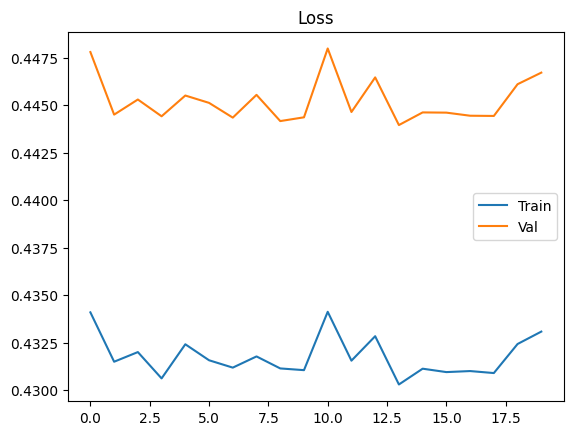

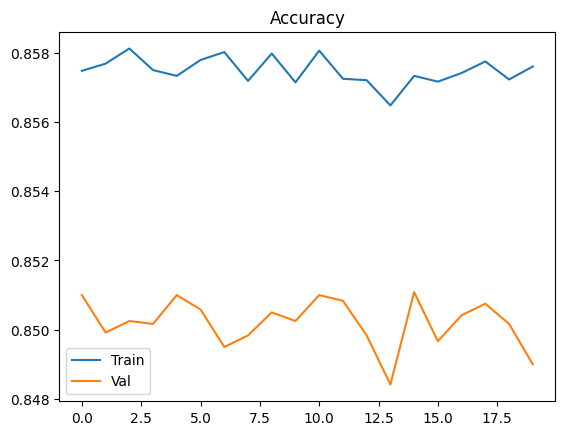

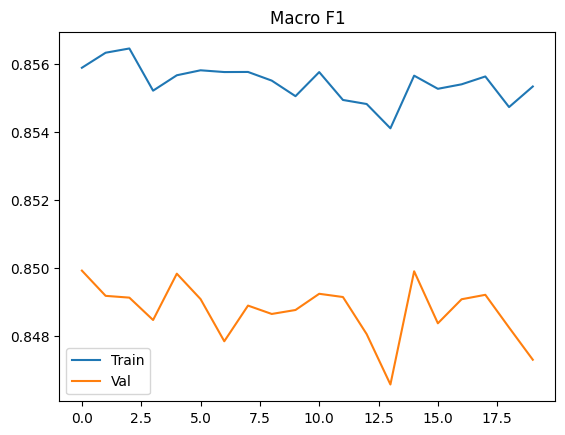

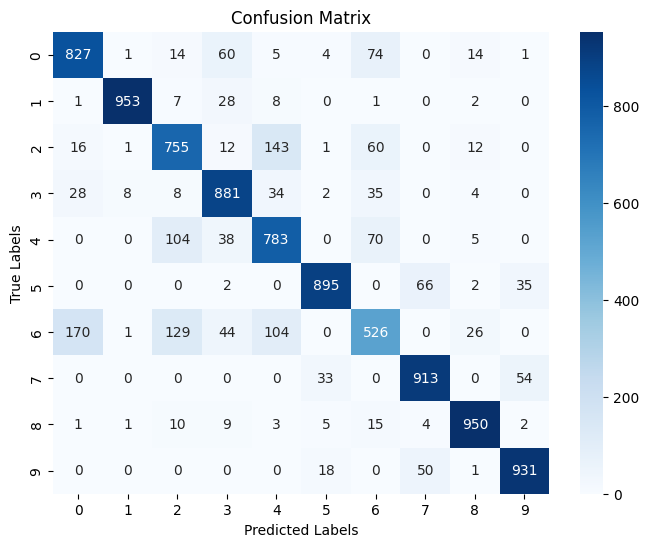

Accuracy:  0.8414  Loss:  0.4704223736902727  Macro F1:  0.8392895353511763
More Random alpha:  0.01 decay: 0.99 dropout: 0.5 optimizer: YOGI


Epoch 1/50: 100%|██████████| 30/30 [00:00<00:00, 32.95it/s]


Epoch:  1
Train
Accuracy:  0.857125  Loss:  0.4332701426957742  Macro F1:  0.8551483851454584
Val
Accuracy:  0.8514166666666667  Loss:  0.44660090878692005  Macro F1:  0.8499530422782484


Epoch 2/50: 100%|██████████| 30/30 [00:01<00:00, 25.87it/s]


Epoch:  2
Train
Accuracy:  0.8571875  Loss:  0.43530212013585984  Macro F1:  0.8542612250588281
Val
Accuracy:  0.8505833333333334  Loss:  0.4486956146469245  Macro F1:  0.8482306977649673


...

Epoch:  48
Train
Accuracy:  0.8569583333333334  Loss:  0.43117099867699143  Macro F1:  0.8543584099873959
Val
Accuracy:  0.8495833333333334  Loss:  0.4446577945878414  Macro F1:  0.84763877935989


Epoch 49/50: 100%|██████████| 30/30 [00:00<00:00, 35.43it/s]


Epoch:  49
Train
Accuracy:  0.8575833333333334  Loss:  0.43276364383405297  Macro F1:  0.8549765995200765
Val
Accuracy:  0.8498333333333333  Loss:  0.4464187570491397  Macro F1:  0.847678213586121


Epoch 50/50: 100%|██████████| 30/30 [00:00<00:00, 32.34it/s]


Epoch:  50
Train
Accuracy:  0.8570208333333333  Loss:  0.43139973024054307  Macro F1:  0.8553137222267718
Val
Accuracy:  0.84875  Loss:  0.44500300467075093  Macro F1:  0.8475750014529526


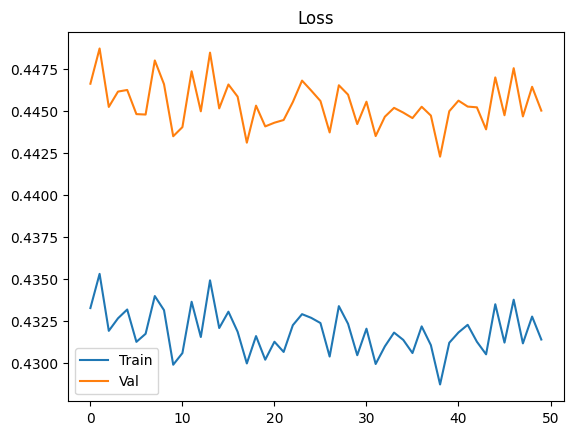

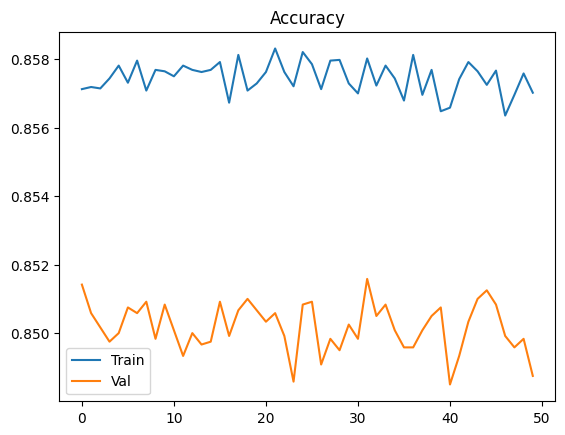

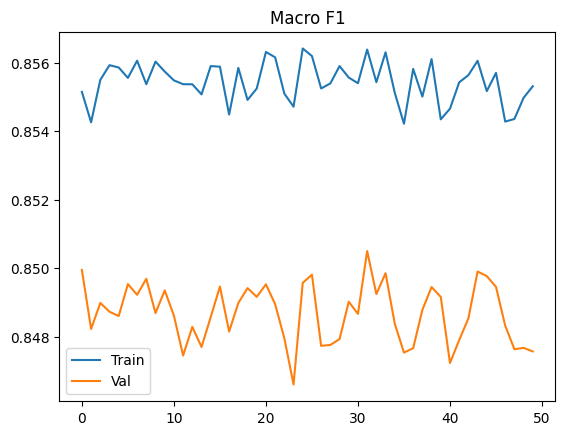

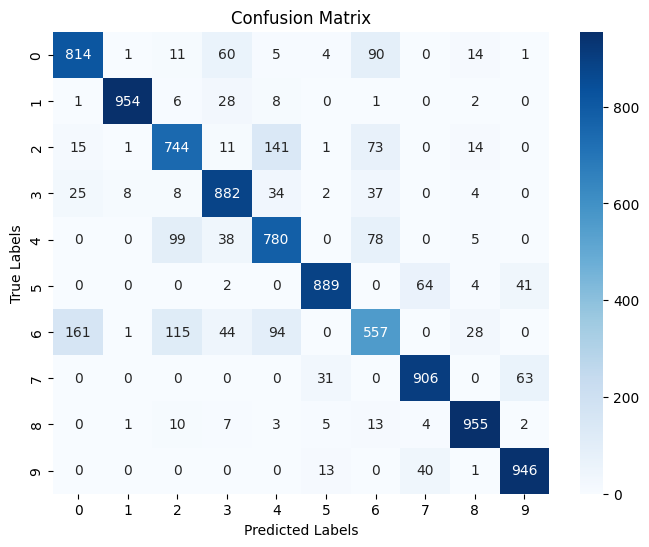

Accuracy:  0.8427  Loss:  0.46957817772070054  Macro F1:  0.8411636738658173
Model 2. 2
Sequential alpha:  0.001 decay: 0.999 dropout: 0.5 optimizer: YOGI


Epoch 1/20: 100%|██████████| 375/375 [00:10<00:00, 35.84it/s]


Epoch:  1
Train
Accuracy:  0.8509375  Loss:  0.5358344211260809  Macro F1:  0.8486534984481569
Val
Accuracy:  0.8458333333333333  Loss:  0.5497232844828075  Macro F1:  0.844044048492741


Epoch 2/20: 100%|██████████| 375/375 [00:10<00:00, 34.96it/s]


Epoch:  2
Train
Accuracy:  0.8695625  Loss:  0.4382758052808786  Macro F1:  0.8676028598183432
Val
Accuracy:  0.8603333333333333  Loss:  0.458216601205818  Macro F1:  0.8584799202354088


...

Epoch:  18
Train
Accuracy:  0.8957083333333333  Loss:  0.3307789129564501  Macro F1:  0.8951042531814885
Val
Accuracy:  0.8816666666666667  Loss:  0.36714583416899116  Macro F1:  0.8811637955731444


Epoch 19/20: 100%|██████████| 375/375 [00:10<00:00, 35.72it/s]


Epoch:  19
Train
Accuracy:  0.8956041666666666  Loss:  0.3312395114164263  Macro F1:  0.894948799320116
Val
Accuracy:  0.8815  Loss:  0.3675266892146687  Macro F1:  0.8809051963960872


Epoch 20/20: 100%|██████████| 375/375 [00:11<00:00, 33.81it/s]


Epoch:  20
Train
Accuracy:  0.8955833333333333  Loss:  0.3296726731633507  Macro F1:  0.8951324686639118
Val
Accuracy:  0.8814166666666666  Loss:  0.36607319872893995  Macro F1:  0.881093449058495


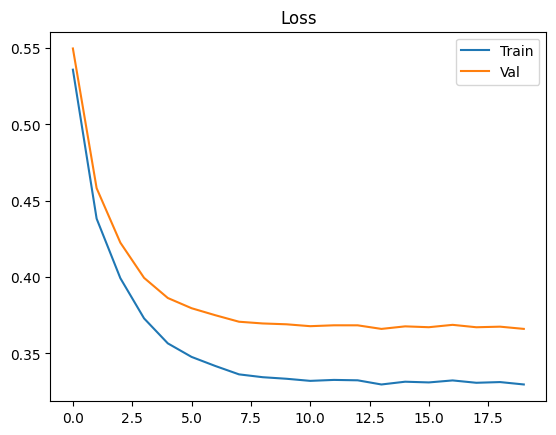

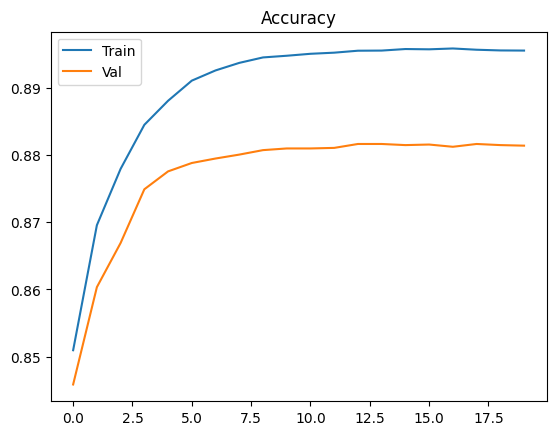

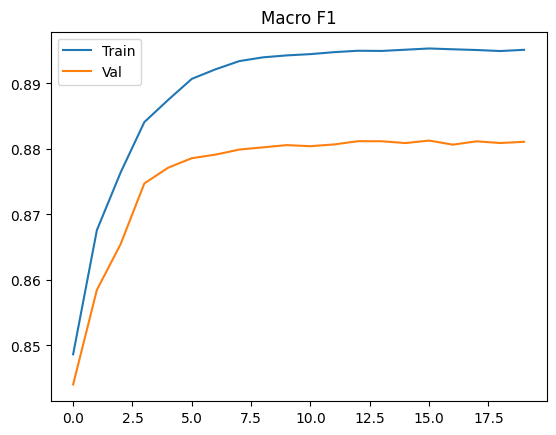

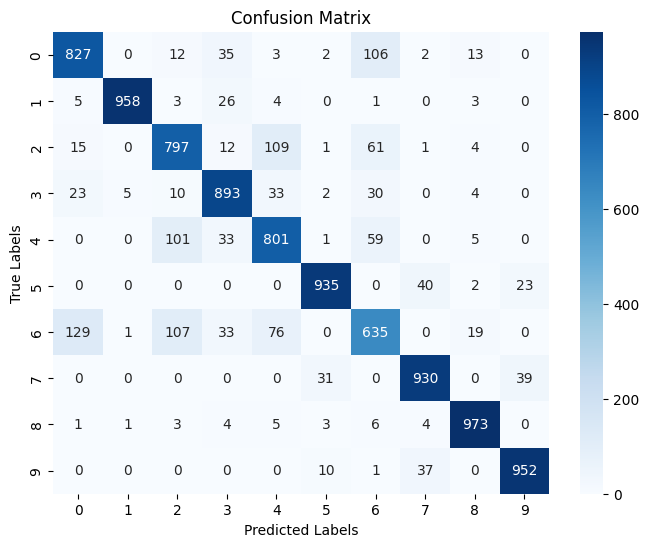

Accuracy:  0.8701  Loss:  0.3932989447971454  Macro F1:  0.8693804616286362
Random alpha:  0.001 decay: 0.999 dropout: 0.5 optimizer: YOGI


Epoch 1/20: 100%|██████████| 375/375 [00:11<00:00, 33.61it/s]


Epoch:  1
Train
Accuracy:  0.8959791666666667  Loss:  0.33172497357785263  Macro F1:  0.8955241887368084
Val
Accuracy:  0.8805833333333334  Loss:  0.3674085088115298  Macro F1:  0.8803395401769818


Epoch 2/20: 100%|██████████| 375/375 [00:12<00:00, 30.98it/s]


Epoch:  2
Train
Accuracy:  0.896375  Loss:  0.3298007784361955  Macro F1:  0.8957905782007419
Val
Accuracy:  0.8816666666666667  Loss:  0.3658548076087915  Macro F1:  0.8811964073158917


...

Epoch:  18
Train
Accuracy:  0.896  Loss:  0.33015053382544746  Macro F1:  0.895606936759744
Val
Accuracy:  0.8816666666666667  Loss:  0.36643547356799244  Macro F1:  0.8813855797884551


Epoch 19/20: 100%|██████████| 375/375 [00:10<00:00, 34.92it/s]


Epoch:  19
Train
Accuracy:  0.8962291666666666  Loss:  0.3307290964018691  Macro F1:  0.8954860075031197
Val
Accuracy:  0.88225  Loss:  0.36706877115102227  Macro F1:  0.8815937818444611


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 34.37it/s]


Epoch:  20
Train
Accuracy:  0.8956458333333334  Loss:  0.33135183670790636  Macro F1:  0.8953939765487465
Val
Accuracy:  0.8821666666666667  Loss:  0.3673091127190342  Macro F1:  0.8820613683349098


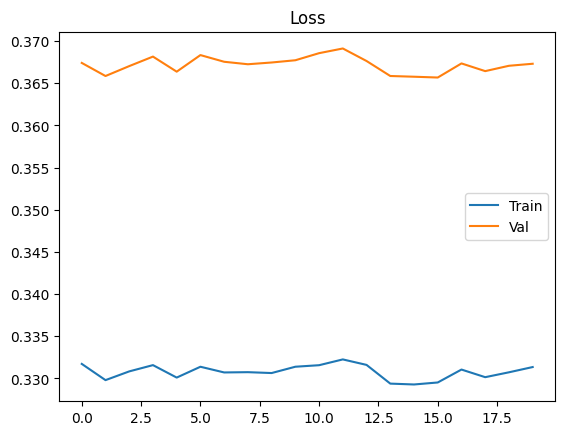

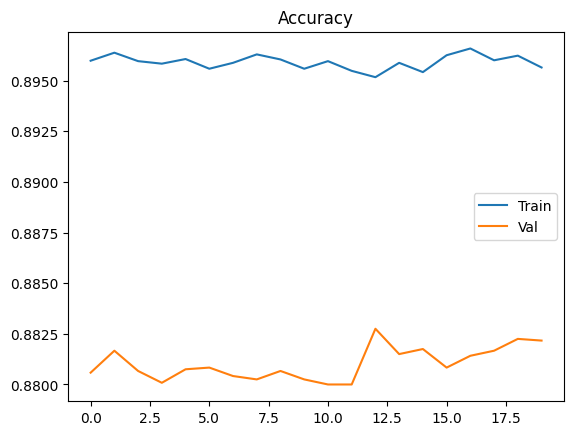

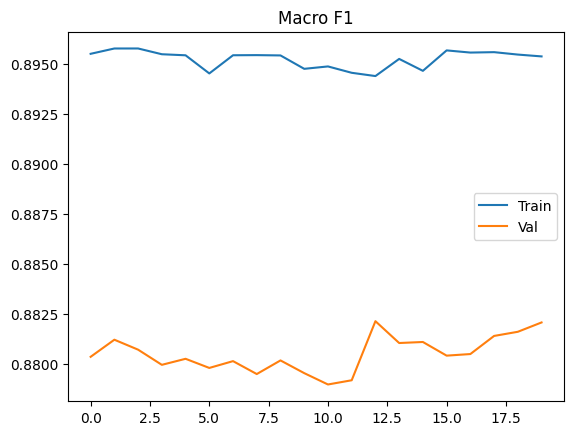

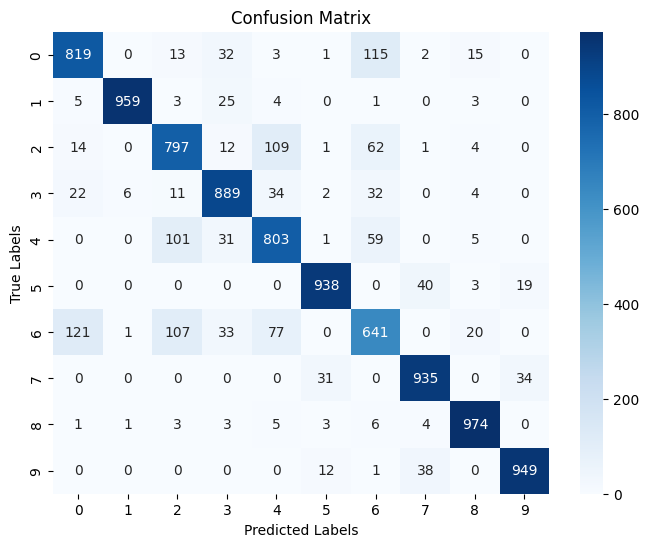

Accuracy:  0.8704  Loss:  0.3947472525483503  Macro F1:  0.8698320755563719
More Random alpha:  0.001 decay: 0.999 dropout: 0.5 optimizer: YOGI


Epoch 1/50: 100%|██████████| 30/30 [00:00<00:00, 35.37it/s]


Epoch:  1
Train
Accuracy:  0.8955625  Loss:  0.32894057914764924  Macro F1:  0.8947698319572149
Val
Accuracy:  0.8810833333333333  Loss:  0.3661163388028075  Macro F1:  0.8804062351083196


Epoch 2/50: 100%|██████████| 30/30 [00:00<00:00, 35.48it/s]


Epoch:  2
Train
Accuracy:  0.8957708333333333  Loss:  0.329754033639607  Macro F1:  0.895233401103449
Val
Accuracy:  0.882  Loss:  0.3661042820043581  Macro F1:  0.8816043001472817


...

Epoch:  48
Train
Accuracy:  0.8956875  Loss:  0.3285627674156453  Macro F1:  0.8950422862081165
Val
Accuracy:  0.8811666666666667  Loss:  0.3647800010471346  Macro F1:  0.8805990276100323


Epoch 49/50: 100%|██████████| 30/30 [00:00<00:00, 33.99it/s]


Epoch:  49
Train
Accuracy:  0.8955833333333333  Loss:  0.32894702745415955  Macro F1:  0.8948080021897823
Val
Accuracy:  0.8800833333333333  Loss:  0.3656051941316606  Macro F1:  0.879404590888463


Epoch 50/50: 100%|██████████| 30/30 [00:00<00:00, 34.71it/s]


Epoch:  50
Train
Accuracy:  0.8955833333333333  Loss:  0.32910095522485383  Macro F1:  0.8951419581317899
Val
Accuracy:  0.8819166666666667  Loss:  0.3659037611707243  Macro F1:  0.8815748167353032


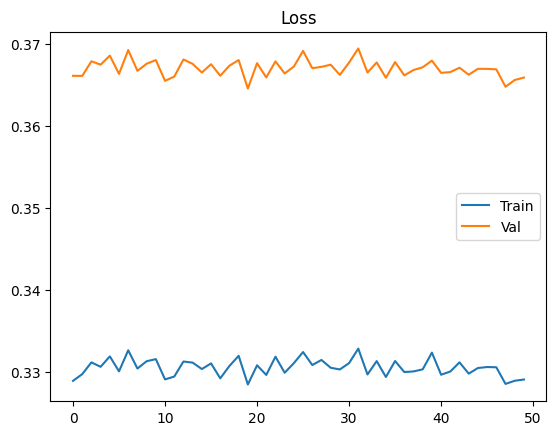

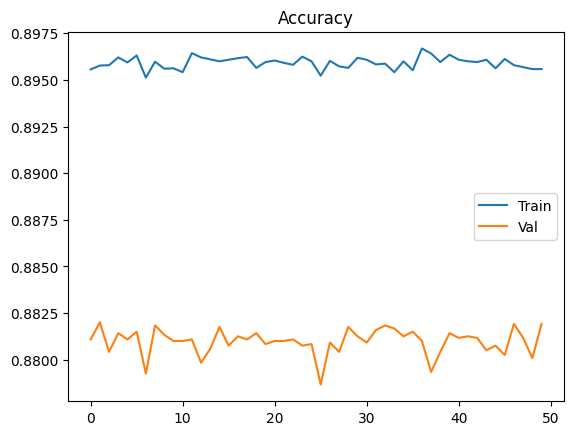

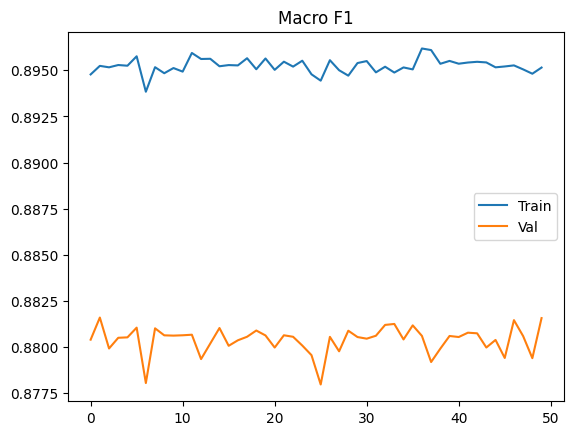

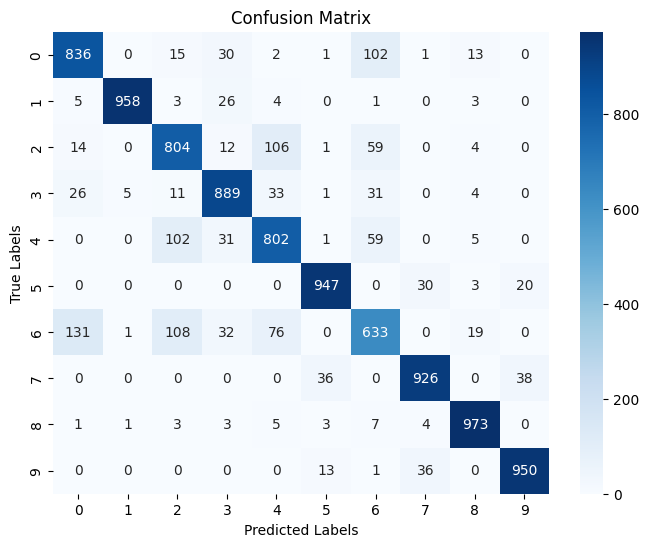

Accuracy:  0.8718  Loss:  0.392715074998637  Macro F1:  0.8710838234015916
Model 2. 3
Sequential alpha:  0.00078125 decay: 0.9999 dropout: 0.5 optimizer: YOGI


Epoch 1/20: 100%|██████████| 375/375 [00:10<00:00, 36.51it/s]


Epoch:  1
Train
Accuracy:  0.8415416666666666  Loss:  0.5607805145638963  Macro F1:  0.8390532042369602
Val
Accuracy:  0.8368333333333333  Loss:  0.5740167395283245  Macro F1:  0.8346582575584416


Epoch 2/20: 100%|██████████| 375/375 [00:10<00:00, 36.71it/s]


Epoch:  2
Train
Accuracy:  0.8611666666666666  Loss:  0.4587851436059118  Macro F1:  0.8597244237886598
Val
Accuracy:  0.8541666666666666  Loss:  0.4756446679851556  Macro F1:  0.8529105409994109


...

Epoch:  18
Train
Accuracy:  0.9252083333333333  Loss:  0.21357341708474892  Macro F1:  0.9247966412505504
Val
Accuracy:  0.8926666666666667  Loss:  0.29994958106066083  Macro F1:  0.8924388077413413


Epoch 19/20: 100%|██████████| 375/375 [00:10<00:00, 36.38it/s]


Epoch:  19
Train
Accuracy:  0.9282916666666666  Loss:  0.20462469355076662  Macro F1:  0.9280397367919306
Val
Accuracy:  0.8954166666666666  Loss:  0.29428349538602155  Macro F1:  0.8953628313027553


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 37.11it/s]


Epoch:  20
Train
Accuracy:  0.9300625  Loss:  0.20137625373450058  Macro F1:  0.9297621575808638
Val
Accuracy:  0.8959166666666667  Loss:  0.29254382037194865  Macro F1:  0.8957297574132982


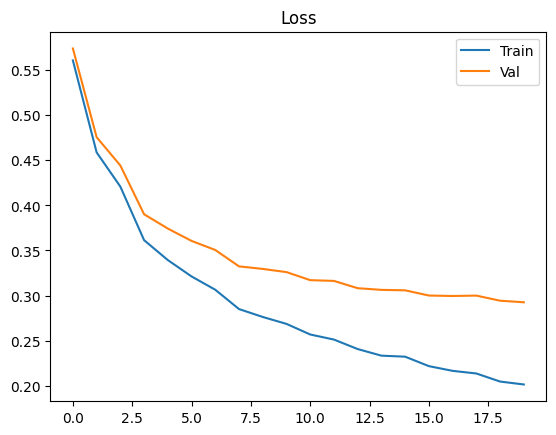

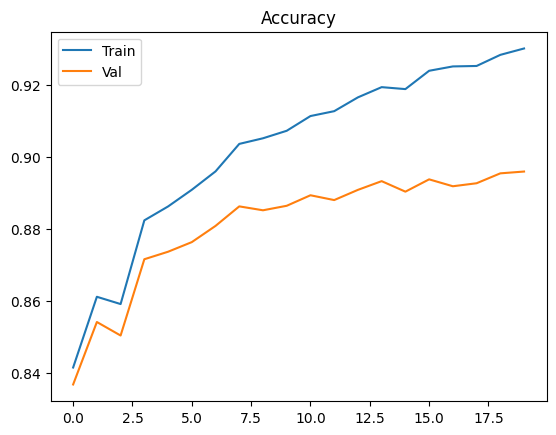

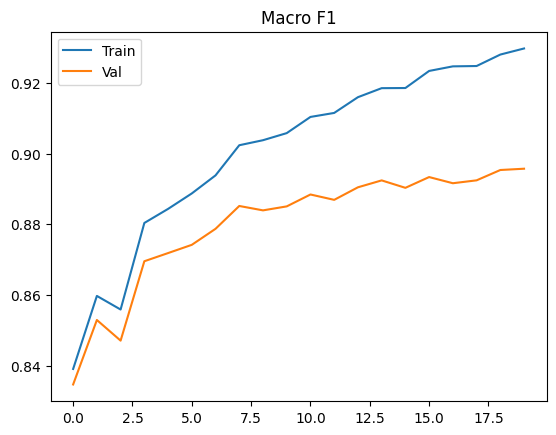

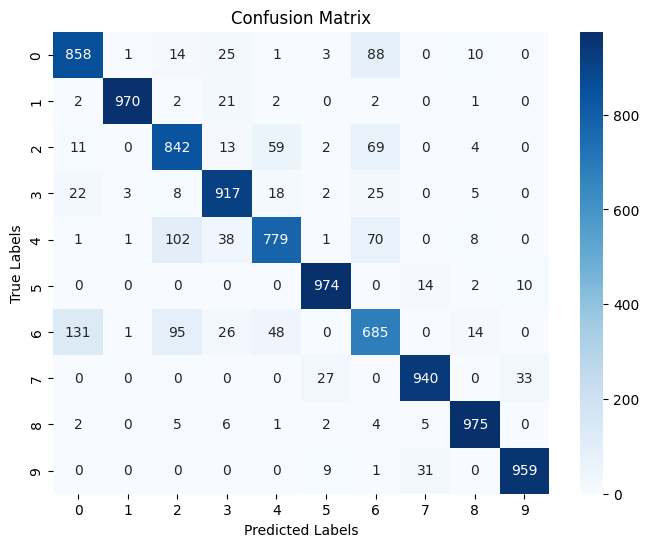

Accuracy:  0.8899  Loss:  0.318870238300483  Macro F1:  0.8893290229673244
Random alpha:  0.00078125 decay: 0.9999 dropout: 0.5 optimizer: YOGI


Epoch 1/20: 100%|██████████| 375/375 [00:10<00:00, 35.62it/s]


Epoch:  1
Train
Accuracy:  0.9328958333333334  Loss:  0.19429850599371654  Macro F1:  0.93248987426858
Val
Accuracy:  0.8961666666666667  Loss:  0.2891865006435297  Macro F1:  0.8958322285199127


Epoch 2/20: 100%|██████████| 375/375 [00:11<00:00, 32.76it/s]


Epoch:  2
Train
Accuracy:  0.9313125  Loss:  0.19449082692578037  Macro F1:  0.9310174031456226
Val
Accuracy:  0.8959166666666667  Loss:  0.28824006701511273  Macro F1:  0.8957273535177768


...

Epoch:  18
Train
Accuracy:  0.9492916666666666  Loss:  0.14768288203335414  Macro F1:  0.9489739426817735
Val
Accuracy:  0.9003333333333333  Loss:  0.27876195305541634  Macro F1:  0.8998005789781078


Epoch 19/20: 100%|██████████| 375/375 [00:10<00:00, 35.24it/s]


Epoch:  19
Train
Accuracy:  0.9507291666666666  Loss:  0.1454349534164691  Macro F1:  0.9503239590130963
Val
Accuracy:  0.9001666666666667  Loss:  0.27951472150436907  Macro F1:  0.8994269612351775


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 34.57it/s]


Epoch:  20
Train
Accuracy:  0.9517916666666667  Loss:  0.14368651546300787  Macro F1:  0.9515823864808318
Val
Accuracy:  0.90075  Loss:  0.2803524105660414  Macro F1:  0.9005968640708429


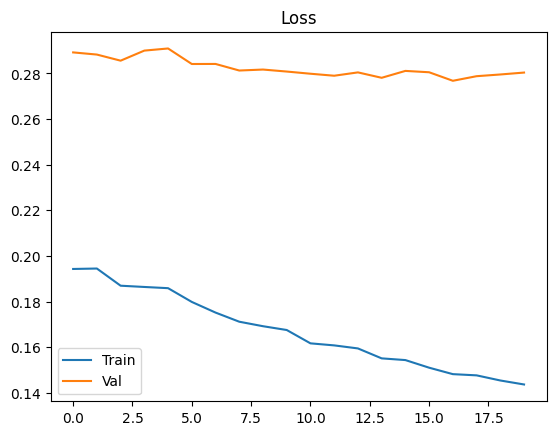

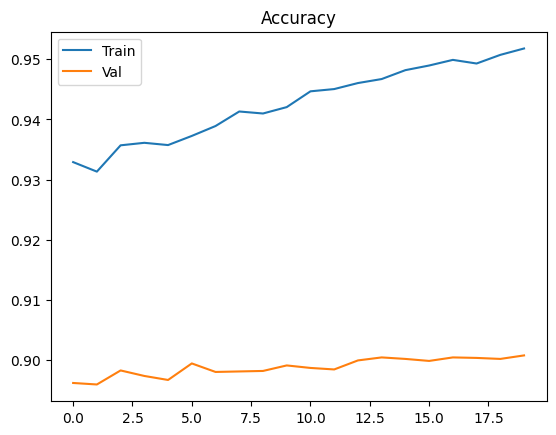

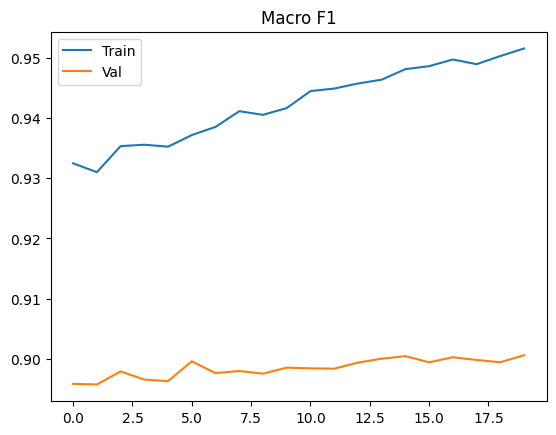

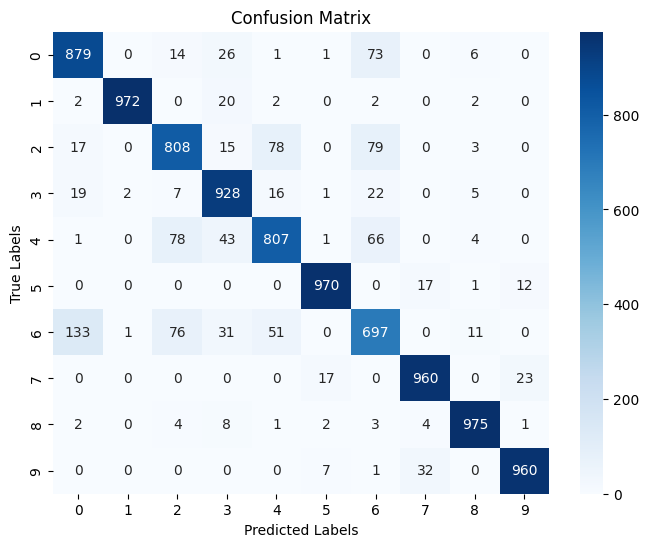

Accuracy:  0.8956  Loss:  0.3004835432541663  Macro F1:  0.8950492829903005
More Random alpha:  0.00078125 decay: 0.9999 dropout: 0.5 optimizer: YOGI


Epoch 1/50: 100%|██████████| 30/30 [00:00<00:00, 35.03it/s]


Epoch:  1
Train
Accuracy:  0.9517083333333334  Loss:  0.14126602233748056  Macro F1:  0.9514921363535036
Val
Accuracy:  0.9011666666666667  Loss:  0.2786699853452737  Macro F1:  0.900819642524487


Epoch 2/50: 100%|██████████| 30/30 [00:00<00:00, 34.30it/s]


Epoch:  2
Train
Accuracy:  0.9529583333333334  Loss:  0.14263502018080876  Macro F1:  0.9528416004509938
Val
Accuracy:  0.8999166666666667  Loss:  0.27891821376508097  Macro F1:  0.8999771567907316


...

Epoch:  48
Train
Accuracy:  0.9548541666666667  Loss:  0.1363275113649597  Macro F1:  0.9546487438392438
Val
Accuracy:  0.9028333333333334  Loss:  0.27612886009196486  Macro F1:  0.9024108737361424


Epoch 49/50: 100%|██████████| 30/30 [00:00<00:00, 36.06it/s]


Epoch:  49
Train
Accuracy:  0.95425  Loss:  0.13638738584502122  Macro F1:  0.9540345501738855
Val
Accuracy:  0.9015833333333333  Loss:  0.27848273372670956  Macro F1:  0.901286164167469


Epoch 50/50: 100%|██████████| 30/30 [00:00<00:00, 35.64it/s]


Epoch:  50
Train
Accuracy:  0.9548125  Loss:  0.13556575999090478  Macro F1:  0.9546477494106475
Val
Accuracy:  0.90175  Loss:  0.2760499035678887  Macro F1:  0.9014493633503431


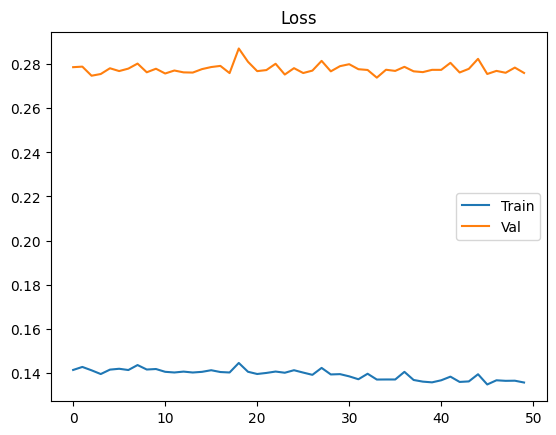

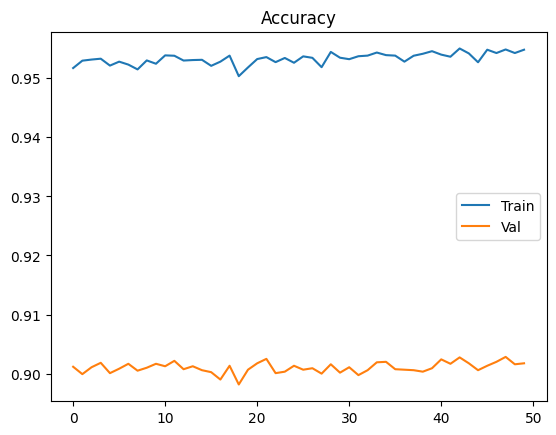

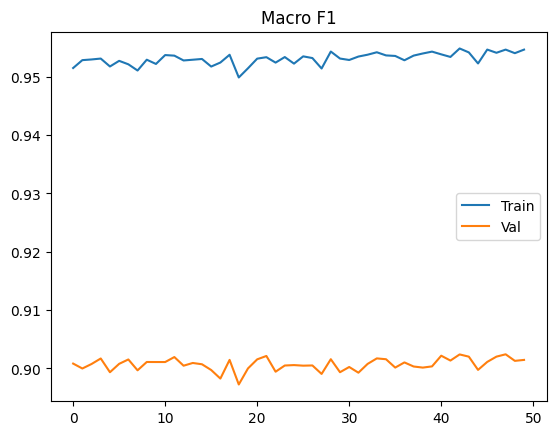

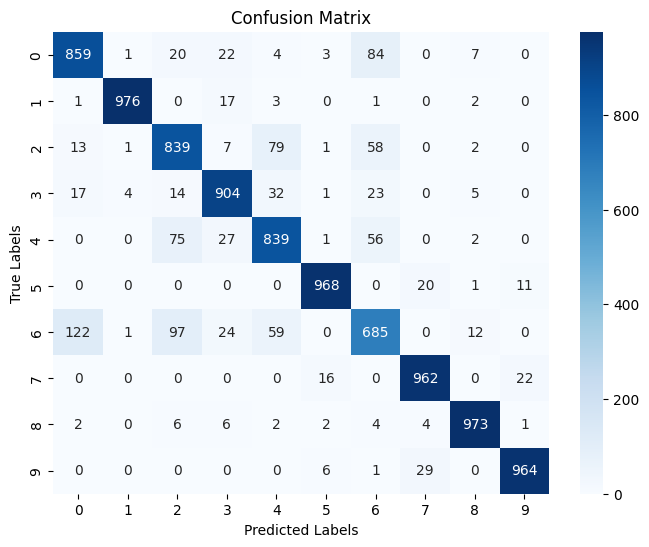

Accuracy:  0.8969  Loss:  0.29894036244340905  Macro F1:  0.8964254525537363
Model 3. 1
Sequential alpha:  0.01 decay: 0.99 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:08<00:00, 42.65it/s]


Epoch:  1
Train
Accuracy:  0.8543958333333334  Loss:  0.39911658802143585  Macro F1:  0.8529293813997578
Val
Accuracy:  0.8494166666666667  Loss:  0.41079545193700107  Macro F1:  0.8487567889623318


Epoch 2/20: 100%|██████████| 375/375 [00:08<00:00, 42.30it/s]


Epoch:  2
Train
Accuracy:  0.85675  Loss:  0.39298932514590074  Macro F1:  0.8549289823388161
Val
Accuracy:  0.8530833333333333  Loss:  0.40502139976778606  Macro F1:  0.8520207932991548


...

Epoch:  18
Train
Accuracy:  0.8569375  Loss:  0.39294576492885097  Macro F1:  0.8552333980322183
Val
Accuracy:  0.8524166666666667  Loss:  0.4050407933661033  Macro F1:  0.8515067544029605


Epoch 19/20: 100%|██████████| 375/375 [00:11<00:00, 33.30it/s]


Epoch:  19
Train
Accuracy:  0.8569166666666667  Loss:  0.393094635760287  Macro F1:  0.8551517924293168
Val
Accuracy:  0.8525  Loss:  0.4051816103162388  Macro F1:  0.8515313873598533


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 36.47it/s]


Epoch:  20
Train
Accuracy:  0.8569791666666666  Loss:  0.39298713091107773  Macro F1:  0.8551979732153312
Val
Accuracy:  0.8529166666666667  Loss:  0.4050749184884297  Macro F1:  0.8519334216206023


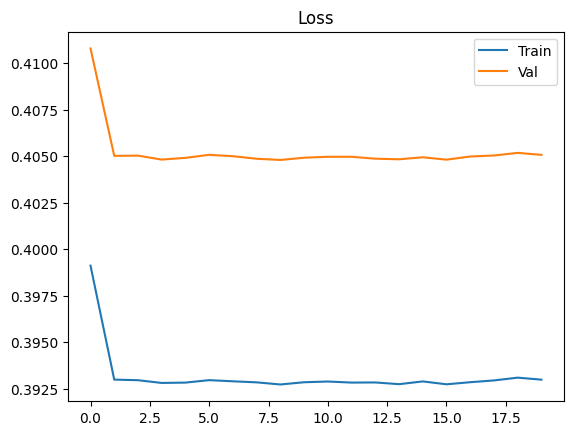

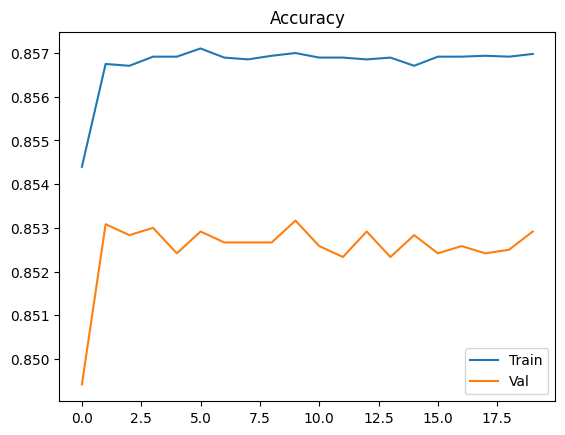

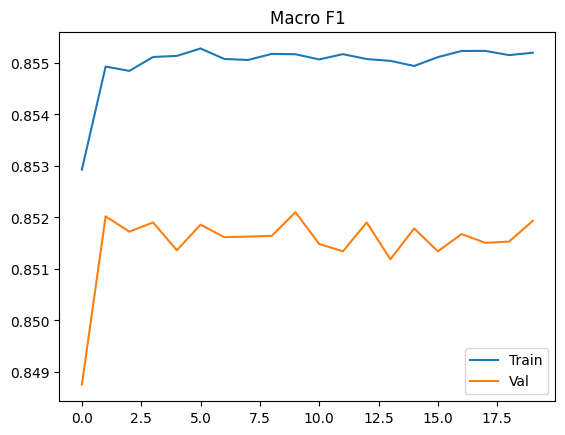

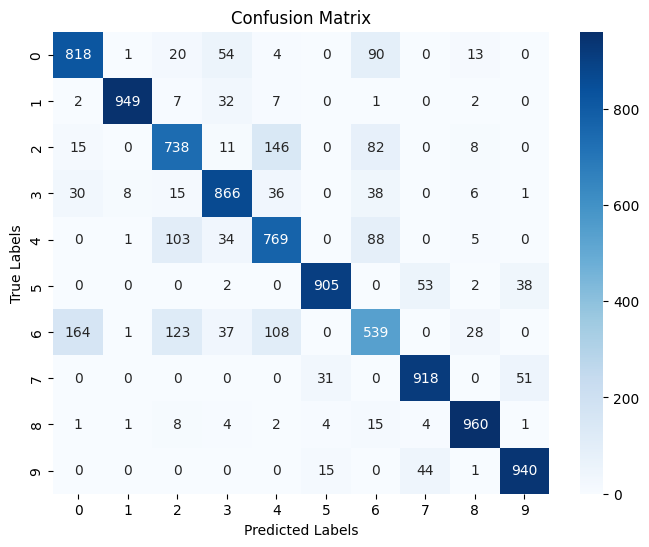

Accuracy:  0.8402  Loss:  0.43602050632465383  Macro F1:  0.838870449195251
Random alpha:  0.01 decay: 0.99 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:11<00:00, 33.76it/s]


Epoch:  1
Train
Accuracy:  0.8565416666666666  Loss:  0.39178780037087174  Macro F1:  0.8550463022534718
Val
Accuracy:  0.8521666666666666  Loss:  0.4039408953418918  Macro F1:  0.8513818168490452


Epoch 2/20: 100%|██████████| 375/375 [00:10<00:00, 34.75it/s]


Epoch:  2
Train
Accuracy:  0.856625  Loss:  0.3926737748409223  Macro F1:  0.8545670154394214
Val
Accuracy:  0.8509166666666667  Loss:  0.4049891632413387  Macro F1:  0.8494592266582268


...

Epoch:  18
Train
Accuracy:  0.8562291666666667  Loss:  0.39309816794134755  Macro F1:  0.8540804546005674
Val
Accuracy:  0.8509166666666667  Loss:  0.4047719071403149  Macro F1:  0.8495950666313897


Epoch 19/20: 100%|██████████| 375/375 [00:12<00:00, 29.66it/s]


Epoch:  19
Train
Accuracy:  0.8566666666666667  Loss:  0.39209239365493437  Macro F1:  0.8549503957370181
Val
Accuracy:  0.8535  Loss:  0.4046824954609639  Macro F1:  0.8526021721054416


Epoch 20/20: 100%|██████████| 375/375 [00:11<00:00, 33.71it/s]


Epoch:  20
Train
Accuracy:  0.856  Loss:  0.3927723042370384  Macro F1:  0.8543605749839152
Val
Accuracy:  0.8504166666666667  Loss:  0.4043734041371395  Macro F1:  0.8493917712007727


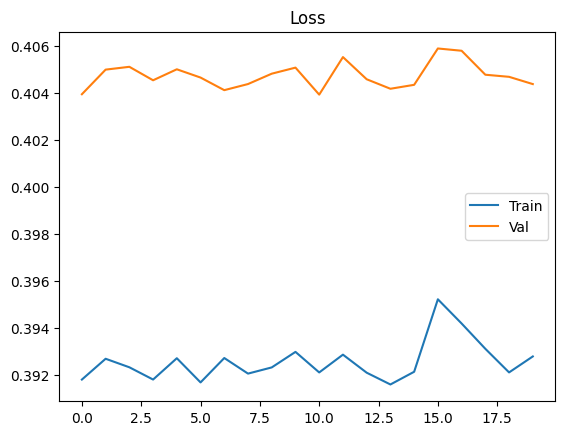

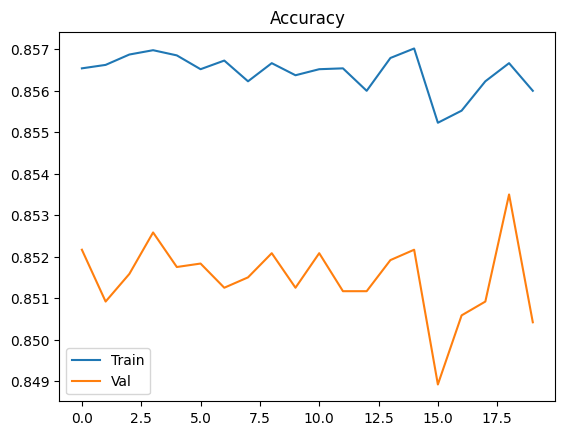

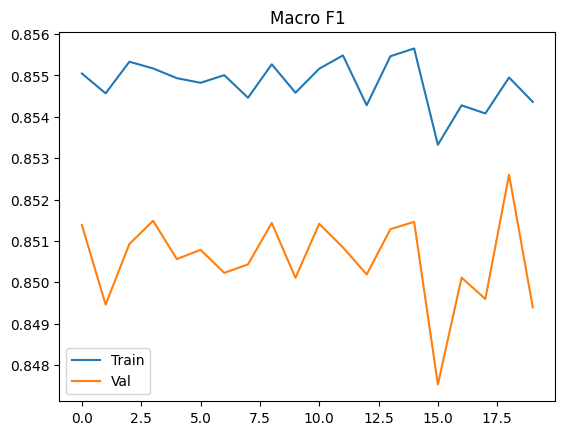

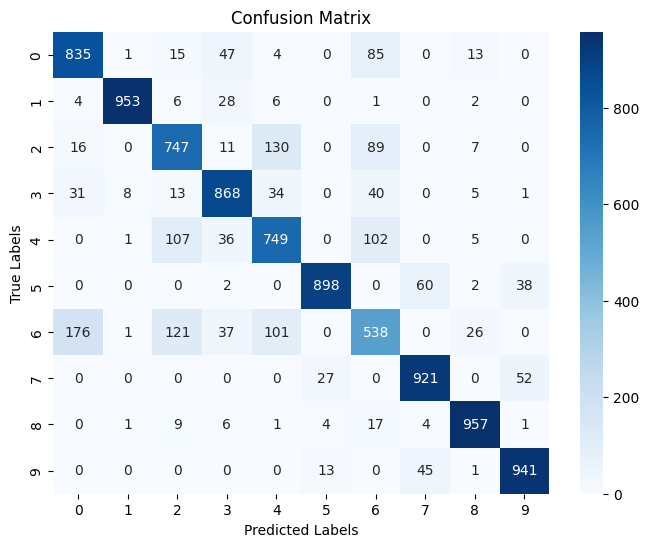

Accuracy:  0.8407  Loss:  0.43321391650069296  Macro F1:  0.8394213784083651
More Random alpha:  0.01 decay: 0.99 dropout: 0.5 optimizer: ADAM


Epoch 1/50: 100%|██████████| 30/30 [00:00<00:00, 33.57it/s]


Epoch:  1
Train
Accuracy:  0.8566875  Loss:  0.39341565652739297  Macro F1:  0.8544874191028207
Val
Accuracy:  0.8508333333333333  Loss:  0.4050236165545198  Macro F1:  0.8492418340661713


Epoch 2/50: 100%|██████████| 30/30 [00:00<00:00, 30.32it/s]


Epoch:  2
Train
Accuracy:  0.8569375  Loss:  0.3928896055905836  Macro F1:  0.8547707804135752
Val
Accuracy:  0.8515833333333334  Loss:  0.40492209427986725  Macro F1:  0.8501184908641649


...

Epoch:  48
Train
Accuracy:  0.8565208333333333  Loss:  0.39191081357126417  Macro F1:  0.8547130401403548
Val
Accuracy:  0.8524166666666667  Loss:  0.4040676831796458  Macro F1:  0.851329079353194


Epoch 49/50: 100%|██████████| 30/30 [00:00<00:00, 32.57it/s]


Epoch:  49
Train
Accuracy:  0.8564583333333333  Loss:  0.3930007986462353  Macro F1:  0.8547092607184595
Val
Accuracy:  0.8518333333333333  Loss:  0.40477240878687426  Macro F1:  0.8507651482742317


Epoch 50/50: 100%|██████████| 30/30 [00:00<00:00, 35.24it/s]


Epoch:  50
Train
Accuracy:  0.8560208333333333  Loss:  0.39316587829482363  Macro F1:  0.8546458033292119
Val
Accuracy:  0.8519166666666667  Loss:  0.4046349511030567  Macro F1:  0.8511395807975684


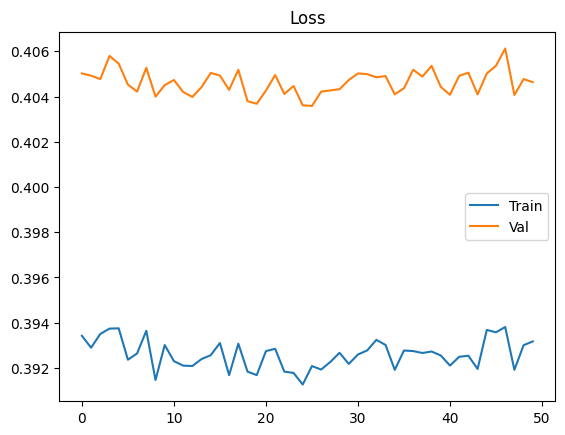

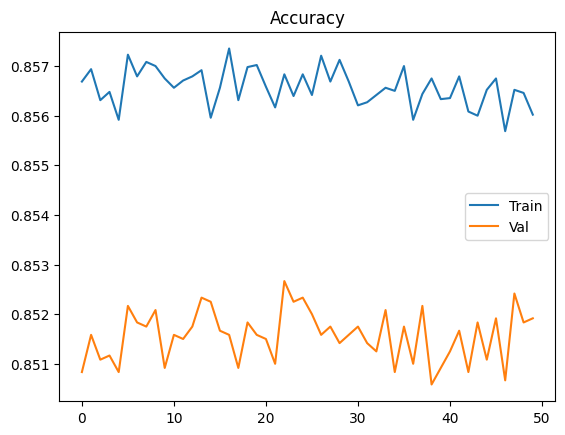

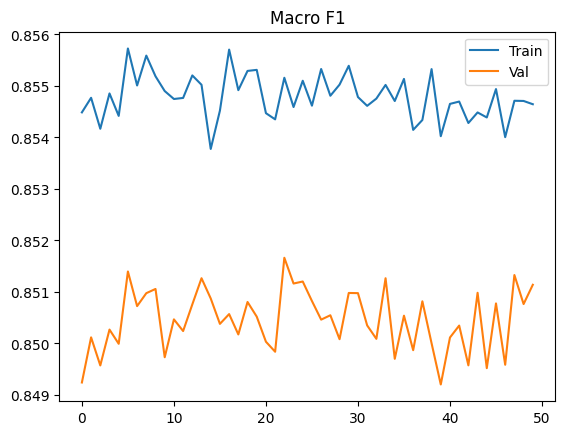

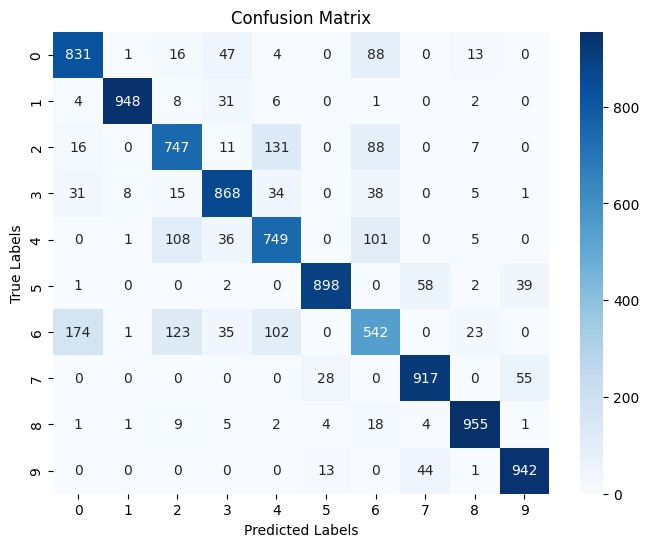

Accuracy:  0.8397  Loss:  0.4330212069438837  Macro F1:  0.8386082428897209
Model 3. 2
Sequential alpha:  0.001 decay: 0.999 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:08<00:00, 42.48it/s]


Epoch:  1
Train
Accuracy:  0.84125  Loss:  0.4309123645763297  Macro F1:  0.837766555187667
Val
Accuracy:  0.8349166666666666  Loss:  0.4486753288401906  Macro F1:  0.8314782871453955


Epoch 2/20: 100%|██████████| 375/375 [00:09<00:00, 37.63it/s]


Epoch:  2
Train
Accuracy:  0.8620416666666667  Loss:  0.3730203468356321  Macro F1:  0.8608077381546876
Val
Accuracy:  0.8553333333333333  Loss:  0.39356850260592946  Macro F1:  0.854456212564845


...

Epoch:  18
Train
Accuracy:  0.8884791666666667  Loss:  0.30062482042305383  Macro F1:  0.8880698275444068
Val
Accuracy:  0.8766666666666667  Loss:  0.337832258044954  Macro F1:  0.8765364414292399


Epoch 19/20: 100%|██████████| 375/375 [00:09<00:00, 41.53it/s]


Epoch:  19
Train
Accuracy:  0.8884583333333333  Loss:  0.300579659192149  Macro F1:  0.887987955871659
Val
Accuracy:  0.8763333333333333  Loss:  0.33787062880863705  Macro F1:  0.8761271728458407


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 36.40it/s]


Epoch:  20
Train
Accuracy:  0.8885  Loss:  0.3005669233523205  Macro F1:  0.8880543571141708
Val
Accuracy:  0.8765  Loss:  0.33789433495061794  Macro F1:  0.8763116576570068


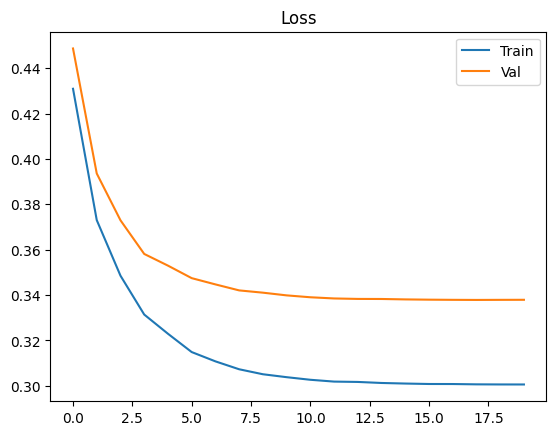

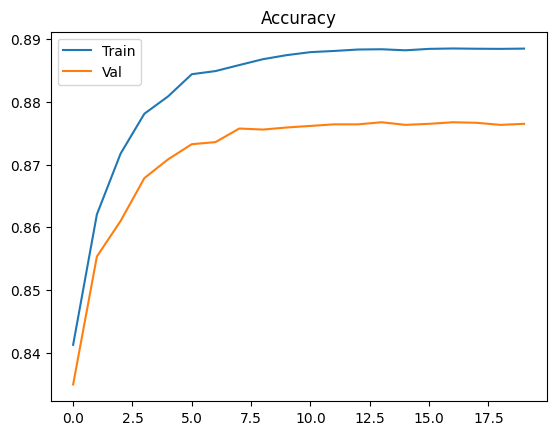

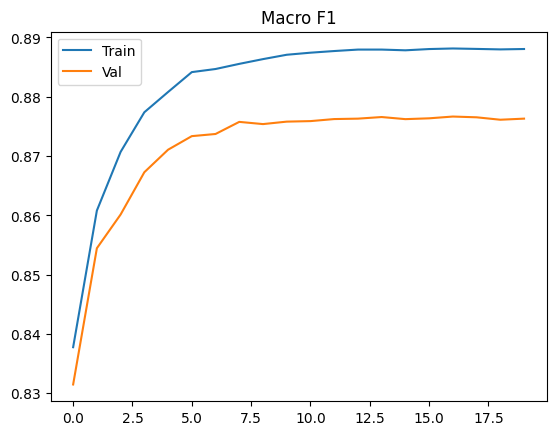

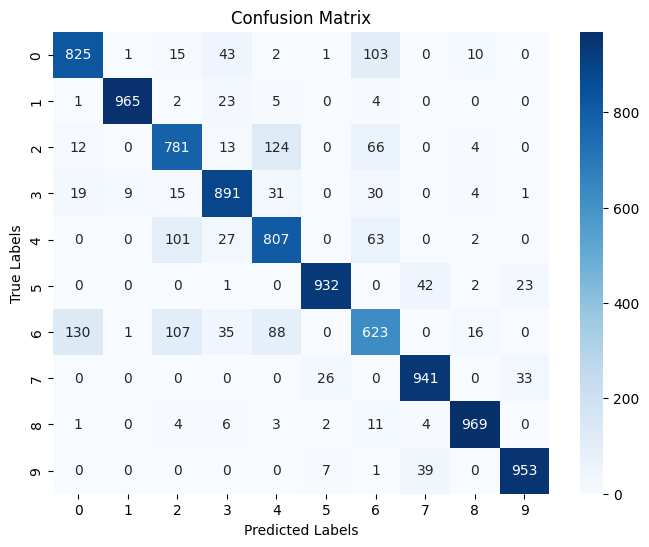

Accuracy:  0.8687  Loss:  0.36427652110289443  Macro F1:  0.8680913517741967
Random alpha:  0.001 decay: 0.999 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:09<00:00, 37.63it/s]


Epoch:  1
Train
Accuracy:  0.8880833333333333  Loss:  0.30145785856123847  Macro F1:  0.8877076639134733
Val
Accuracy:  0.8766666666666667  Loss:  0.338791560311332  Macro F1:  0.8765749555687707


Epoch 2/20: 100%|██████████| 375/375 [00:10<00:00, 35.53it/s]


Epoch:  2
Train
Accuracy:  0.8881666666666667  Loss:  0.3009754777122565  Macro F1:  0.8875089691394109
Val
Accuracy:  0.8765  Loss:  0.3384157678223962  Macro F1:  0.8760711721790578


...

Epoch:  18
Train
Accuracy:  0.8889583333333333  Loss:  0.3012304011824227  Macro F1:  0.8886654036825412
Val
Accuracy:  0.8769166666666667  Loss:  0.3384028759775649  Macro F1:  0.8769519301165534


Epoch 19/20: 100%|██████████| 375/375 [00:10<00:00, 34.16it/s]


Epoch:  19
Train
Accuracy:  0.8886041666666666  Loss:  0.3010204410580468  Macro F1:  0.8883290239676196
Val
Accuracy:  0.8769166666666667  Loss:  0.33817329965834  Macro F1:  0.876879207735664


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 36.15it/s]


Epoch:  20
Train
Accuracy:  0.8885  Loss:  0.3008729323881773  Macro F1:  0.8879043371616255
Val
Accuracy:  0.8766666666666667  Loss:  0.33799883835887773  Macro F1:  0.8763004494311695


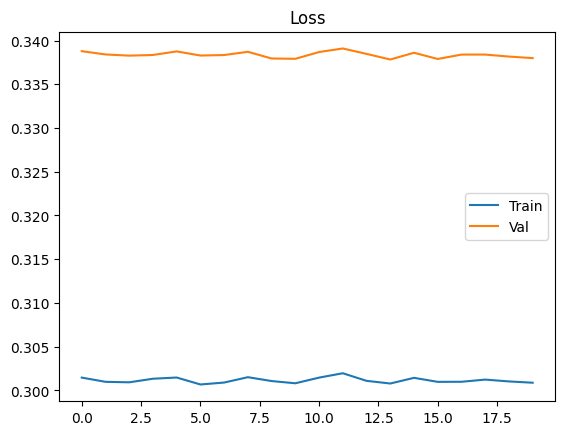

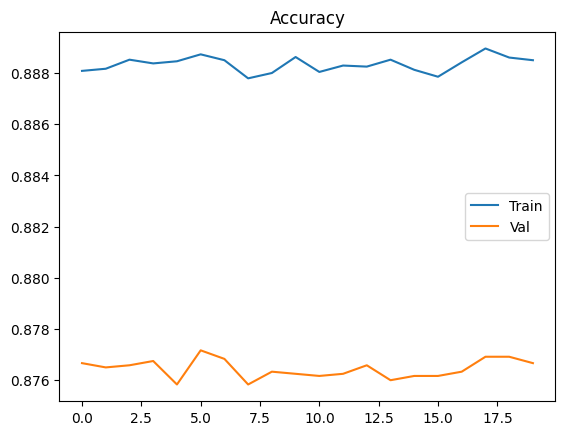

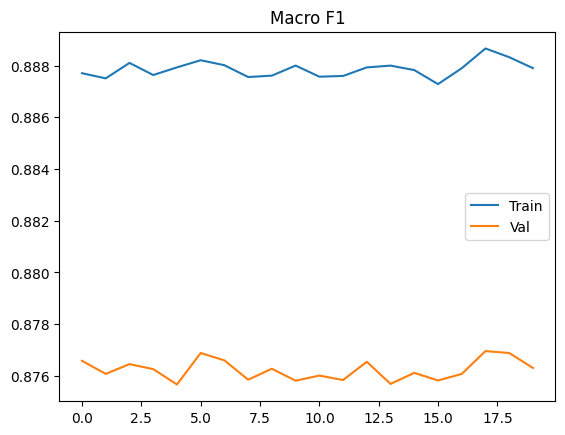

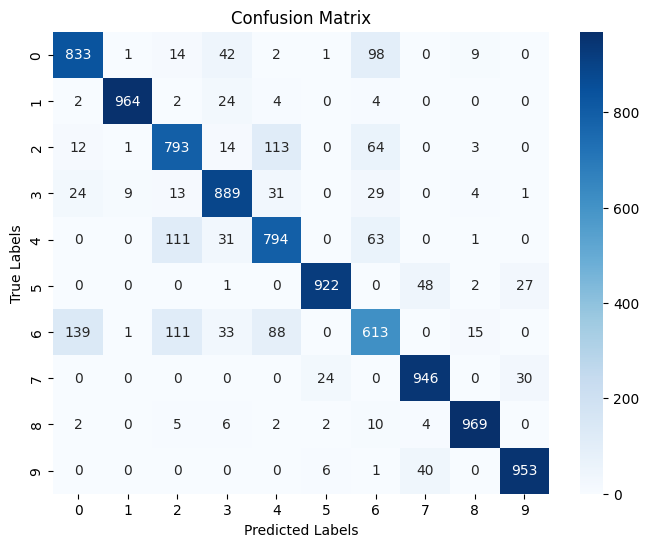

Accuracy:  0.8676  Loss:  0.36449802953160904  Macro F1:  0.8668426820390686
More Random alpha:  0.001 decay: 0.999 dropout: 0.5 optimizer: ADAM


Epoch 1/50: 100%|██████████| 30/30 [00:00<00:00, 37.14it/s]


Epoch:  1
Train
Accuracy:  0.8887708333333333  Loss:  0.300229927329075  Macro F1:  0.8881726500110796
Val
Accuracy:  0.8761666666666666  Loss:  0.33764914156724884  Macro F1:  0.87579455832054


Epoch 2/50: 100%|██████████| 30/30 [00:00<00:00, 37.32it/s]


Epoch:  2
Train
Accuracy:  0.8886041666666666  Loss:  0.3013017997398477  Macro F1:  0.8881522315227794
Val
Accuracy:  0.8775  Loss:  0.3379608950674845  Macro F1:  0.8773338169649885


...

Epoch:  48
Train
Accuracy:  0.8884375  Loss:  0.3013789895520657  Macro F1:  0.8876793459467447
Val
Accuracy:  0.8765833333333334  Loss:  0.33843937571157745  Macro F1:  0.8760138413346514


Epoch 49/50: 100%|██████████| 30/30 [00:00<00:00, 31.14it/s]


Epoch:  49
Train
Accuracy:  0.8880625  Loss:  0.30105096293006  Macro F1:  0.8876139712087825
Val
Accuracy:  0.876  Loss:  0.33783704498520273  Macro F1:  0.8758749210285076


Epoch 50/50: 100%|██████████| 30/30 [00:00<00:00, 35.41it/s]


Epoch:  50
Train
Accuracy:  0.888375  Loss:  0.3012152335817749  Macro F1:  0.8877479938015126
Val
Accuracy:  0.8775  Loss:  0.3386462789683486  Macro F1:  0.8770491284335844


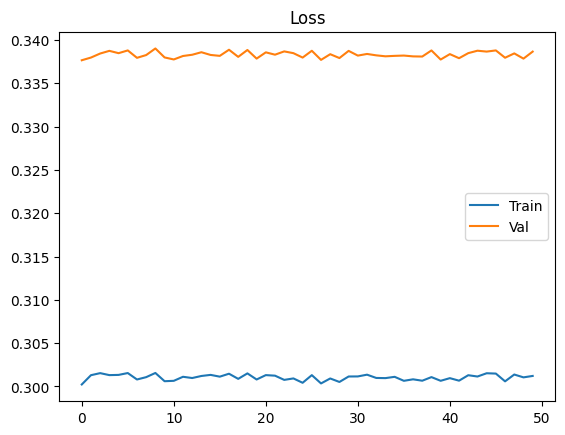

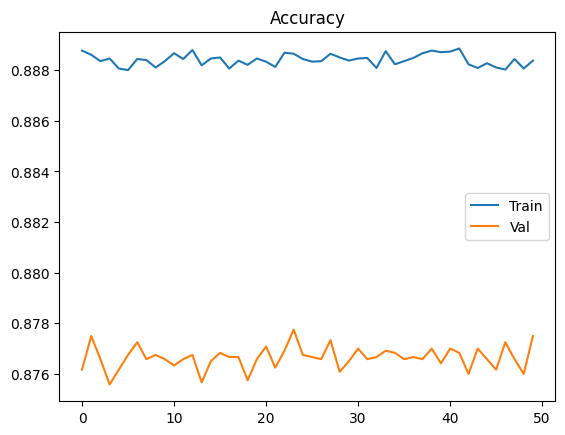

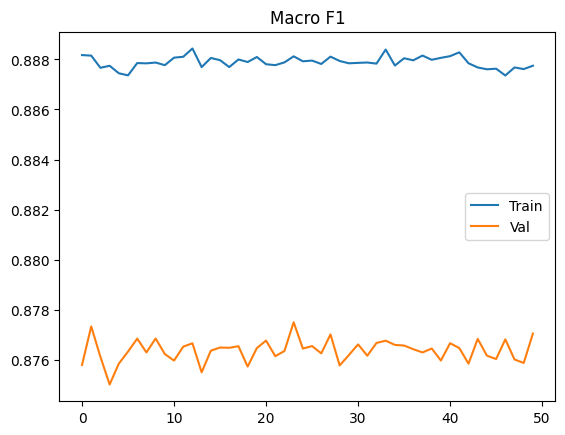

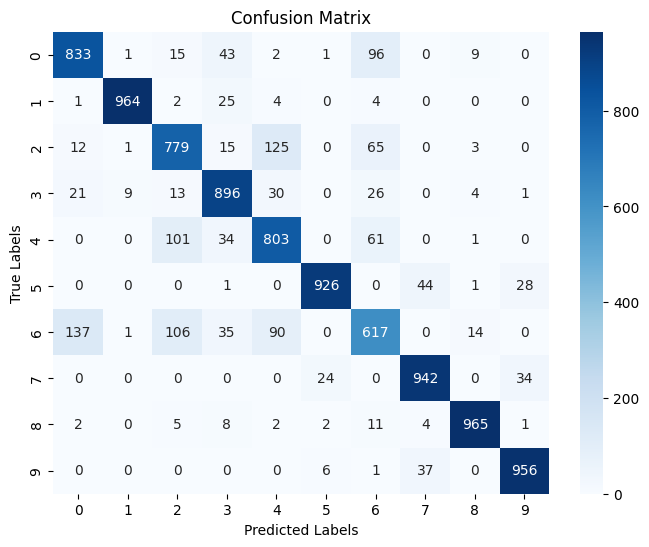

Accuracy:  0.8681  Loss:  0.3647281278380823  Macro F1:  0.8673273523940062
Model 3. 3
Sequential alpha:  0.00078125 decay: 0.9999 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:09<00:00, 37.80it/s]


Epoch:  1
Train
Accuracy:  0.8377708333333334  Loss:  0.4346845002820503  Macro F1:  0.8356037159476039
Val
Accuracy:  0.8323333333333334  Loss:  0.44860360408819017  Macro F1:  0.8303550302653061


Epoch 2/20: 100%|██████████| 375/375 [00:10<00:00, 34.58it/s]


Epoch:  2
Train
Accuracy:  0.8568333333333333  Loss:  0.3843538739046861  Macro F1:  0.8553606143479499
Val
Accuracy:  0.8485  Loss:  0.40449645771376097  Macro F1:  0.8474370548023975


...

Epoch:  18
Train
Accuracy:  0.9115625  Loss:  0.23657959363642528  Macro F1:  0.9112442909107041
Val
Accuracy:  0.8891666666666667  Loss:  0.30774257682252776  Macro F1:  0.8890565325666323


Epoch 19/20: 100%|██████████| 375/375 [00:11<00:00, 34.01it/s]


Epoch:  19
Train
Accuracy:  0.9137083333333333  Loss:  0.23268160543868224  Macro F1:  0.9132922115581156
Val
Accuracy:  0.8889166666666667  Loss:  0.30972367445827964  Macro F1:  0.8887287969210342


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 37.00it/s]


Epoch:  20
Train
Accuracy:  0.9122916666666666  Loss:  0.2347554661654685  Macro F1:  0.9120839725491503
Val
Accuracy:  0.8875  Loss:  0.3132806646308063  Macro F1:  0.8876471654293498


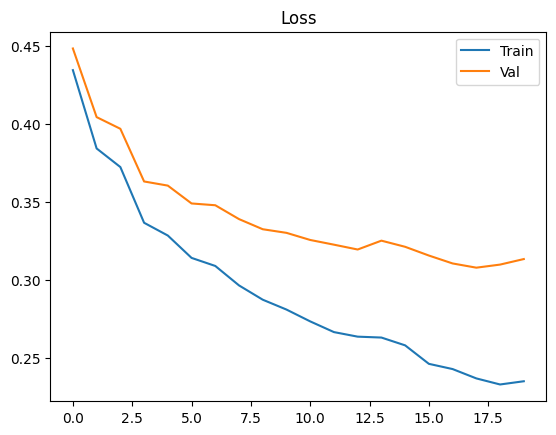

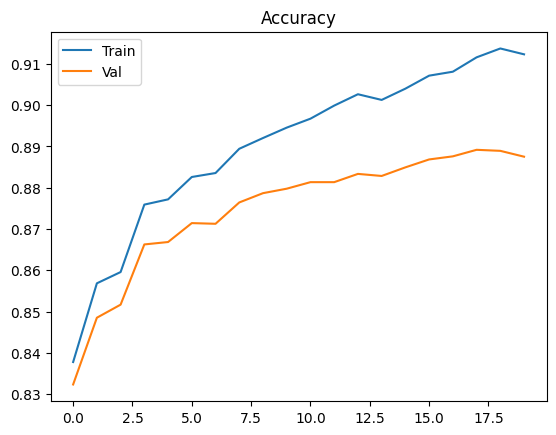

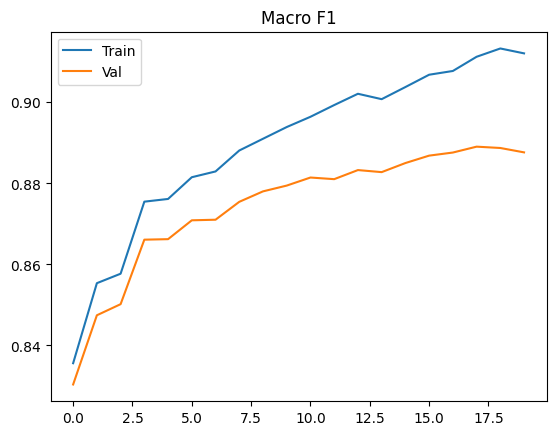

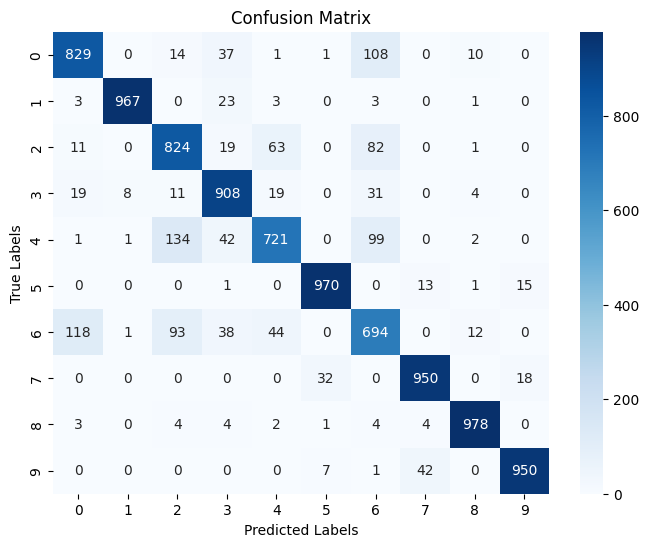

Accuracy:  0.8791  Loss:  0.33797672940489376  Macro F1:  0.8789538779065126
Random alpha:  0.00078125 decay: 0.9999 dropout: 0.5 optimizer: ADAM


Epoch 1/20: 100%|██████████| 375/375 [00:11<00:00, 33.67it/s]


Epoch:  1
Train
Accuracy:  0.914  Loss:  0.22920091304433943  Macro F1:  0.9133867985648616
Val
Accuracy:  0.8888333333333334  Loss:  0.30574996123099696  Macro F1:  0.8885043304711637


Epoch 2/20: 100%|██████████| 375/375 [00:10<00:00, 35.43it/s]


Epoch:  2
Train
Accuracy:  0.9166458333333334  Loss:  0.22308995818395644  Macro F1:  0.9164587889689374
Val
Accuracy:  0.8894166666666666  Loss:  0.30141276515099097  Macro F1:  0.8894815007443906


...

Epoch:  18
Train
Accuracy:  0.9329791666666667  Loss:  0.17927825732798958  Macro F1:  0.9326761462198435
Val
Accuracy:  0.8948333333333334  Loss:  0.29487011267206503  Macro F1:  0.8947097020006674


Epoch 19/20: 100%|██████████| 375/375 [00:10<00:00, 36.70it/s]


Epoch:  19
Train
Accuracy:  0.9340416666666667  Loss:  0.1771680711183712  Macro F1:  0.9335598130361482
Val
Accuracy:  0.897  Loss:  0.29410881652213716  Macro F1:  0.8966104196531622


Epoch 20/20: 100%|██████████| 375/375 [00:10<00:00, 37.29it/s]


Epoch:  20
Train
Accuracy:  0.9346666666666666  Loss:  0.17616423144397214  Macro F1:  0.9344385303945264
Val
Accuracy:  0.8964166666666666  Loss:  0.2938144852964099  Macro F1:  0.8963445416635418


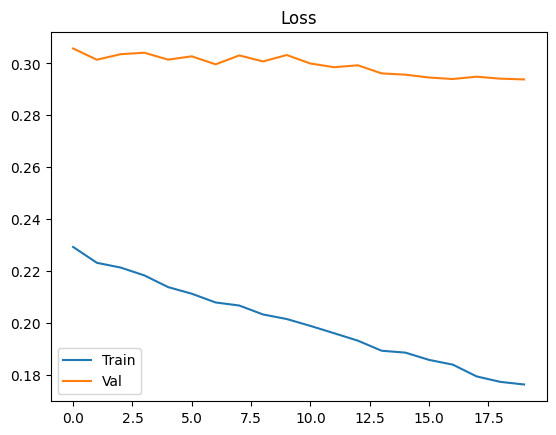

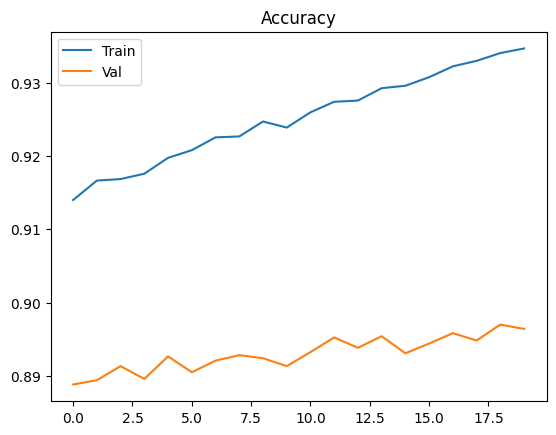

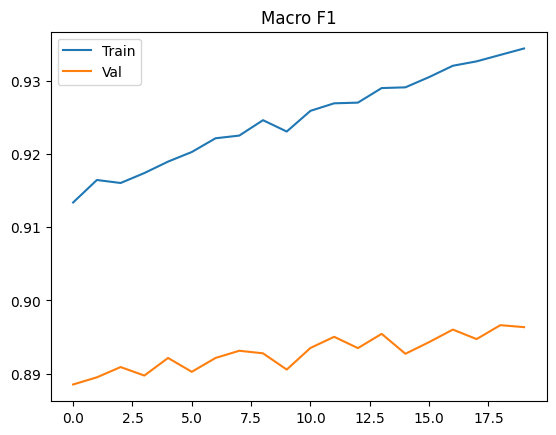

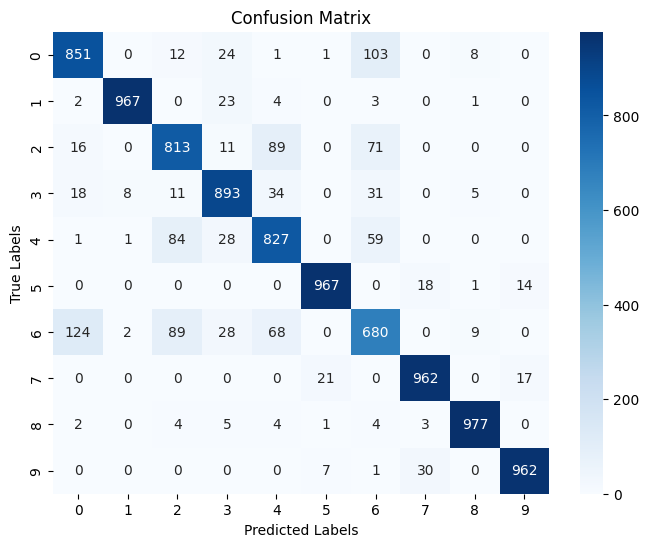

Accuracy:  0.8899  Loss:  0.3170374622068225  Macro F1:  0.8897099456864769
More Random alpha:  0.00078125 decay: 0.9999 dropout: 0.5 optimizer: ADAM


Epoch 1/50: 100%|██████████| 30/30 [00:00<00:00, 36.57it/s]


Epoch:  1
Train
Accuracy:  0.9332291666666667  Loss:  0.1780539586646734  Macro F1:  0.9329340519103677
Val
Accuracy:  0.89675  Loss:  0.293604530787835  Macro F1:  0.8964986571762481


Epoch 2/50: 100%|██████████| 30/30 [00:00<00:00, 37.20it/s]


Epoch:  2
Train
Accuracy:  0.9345  Loss:  0.17754901963476769  Macro F1:  0.934548299776749
Val
Accuracy:  0.8966666666666666  Loss:  0.29297693579090023  Macro F1:  0.8970790715490697


...

Epoch:  48
Train
Accuracy:  0.9366458333333333  Loss:  0.17034095368888347  Macro F1:  0.9364710087664807
Val
Accuracy:  0.89625  Loss:  0.29507288545352184  Macro F1:  0.8962355804650575


Epoch 49/50: 100%|██████████| 30/30 [00:00<00:00, 36.26it/s]


Epoch:  49
Train
Accuracy:  0.9357916666666667  Loss:  0.1695478434135674  Macro F1:  0.9356997712056339
Val
Accuracy:  0.89725  Loss:  0.293765705164379  Macro F1:  0.8973724842536456


Epoch 50/50: 100%|██████████| 30/30 [00:00<00:00, 35.77it/s]


Epoch:  50
Train
Accuracy:  0.93675  Loss:  0.16954432204646847  Macro F1:  0.9365352072106823
Val
Accuracy:  0.89825  Loss:  0.29399505861940006  Macro F1:  0.8981703842595946


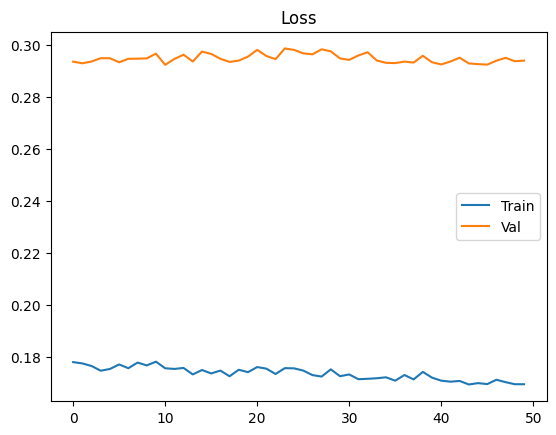

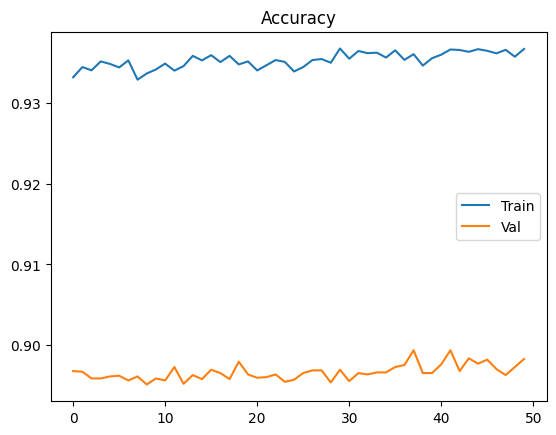

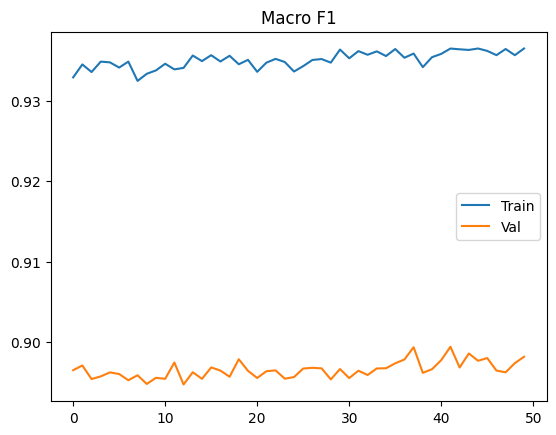

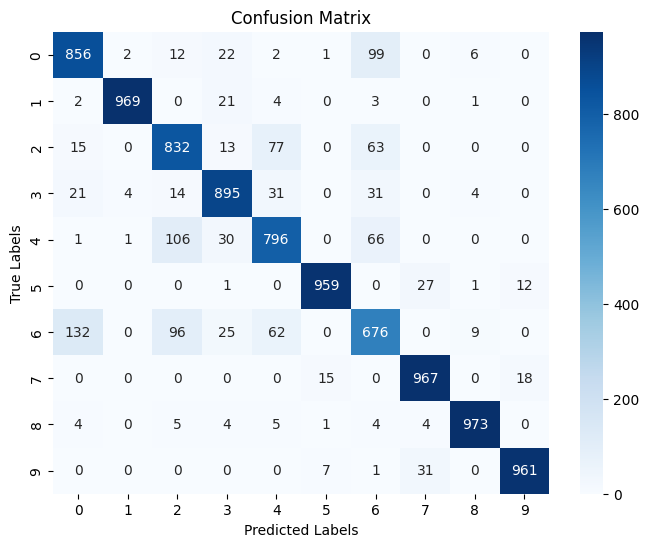

Accuracy:  0.8884  Loss:  0.32047257704338294  Macro F1:  0.8882383113220411


In [7]:
batch_size=128
alphas=[0.01, 0.001, 0.1/batch_size]
decays=[0.99, 0.999, 0.9999]
epch=20
epch2=50

for i in range(3):
    print("Model 1.",i+1)
    model=FNN().MODEL1(alpha=alphas[i],decay=decays[i],itr=1,dropout=0.5)
   
    print("Sequential", "alpha: ",alphas[i], "decay:",decays[i], "dropout: 0.5", "optimizer: ADAM")
    model2=eval.trainSeq(model, epch, batch_size, x_trn, y_trn, x_val, y_val)
    eval.predict(model2, x_test, y_test, cm=True)


    print("Random", "alpha: ",alphas[i], "decay:",decays[i], "dropout: 0.5", "optimizer: ADAM")
    model3=eval.trainRan(model, epch, batch_size, x_trn, y_trn, x_val, y_val)
    eval.predict(model3, x_test, y_test, cm=True)

    print("More Random", "alpha: ",alphas[i], "decay:",decays[i], "dropout: 0.5", "optimizer: ADAM")
    model4=eval.trainMoreRan(model, epch2, batch_size, x_trn, y_trn, x_val, y_val, batch_itr=30)
    eval.predict(model4, x_test, y_test, cm=True)


for i in range(3):
    print("Model 2.",i+1)
    model=FNN().MODEL2(alpha=alphas[i],decay=decays[i],itr=1,dropout=0.5, optimizer="YOGI")
    
    print("Sequential", "alpha: ",alphas[i], "decay:",decays[i], "dropout: 0.5", "optimizer: YOGI")
    model2=eval.trainSeq(model, epch, batch_size, x_trn, y_trn, x_val, y_val)
    eval.predict(model2, x_test, y_test, cm=True)

    print("Random", "alpha: ",alphas[i], "decay:",decays[i], "dropout: 0.5", "optimizer: YOGI")
    model3=eval.trainRan(model, epch, batch_size, x_trn, y_trn, x_val, y_val)
    eval.predict(model3, x_test, y_test, cm=True)

    print("More Random", "alpha: ",alphas[i], "decay:",decays[i], "dropout: 0.5", "optimizer: YOGI")
    model4=eval.trainMoreRan(model, epch2, batch_size, x_trn, y_trn, x_val, y_val, batch_itr=30)
    eval.predict(model4, x_test, y_test, cm=True)


for i in range(3):
    print("Model 3.",i+1)
    model=FNN().MODEL3(alpha=alphas[i],decay=decays[i],itr=1,dropout=0.5, optimizer="ADAM")
    
    print("Sequential", "alpha: ",alphas[i], "decay:",decays[i], "dropout: 0.5", "optimizer: ADAM")
    model2=eval.trainSeq(model, epch, batch_size, x_trn, y_trn, x_val, y_val)
    eval.predict(model2, x_test, y_test, cm=True)

    print("Random", "alpha: ",alphas[i], "decay:",decays[i], "dropout: 0.5", "optimizer: ADAM")
    model3=eval.trainRan(model, epch, batch_size, x_trn, y_trn, x_val, y_val)
    eval.predict(model3, x_test, y_test, cm=True)

    print("More Random", "alpha: ",alphas[i], "decay:",decays[i], "dropout: 0.5", "optimizer: ADAM")
    model4=eval.trainMoreRan(model, epch2, batch_size, x_trn, y_trn, x_val, y_val, batch_itr=30)
    eval.predict(model4, x_test, y_test, cm=True)


In [ ]:
# batch 128 may be better, alpha 0.001 better, Dropout cng kore dekhte hobe. 
# may be 30 itr enough.

# Best Model

In [ ]:
def find_best(model, best_model, best_f1, epoch, batch_size, x_train, y_train, x_val, y_val):  
    eval=Evaluation()
    for i in range(epoch):
        for j in tqdm(range(0,x_train.shape[0],batch_size), desc="Epoch "+str(i+1)+"/"+str(epoch)):
            x_batch=x_train[j:j+batch_size]
            y_batch=y_train[j:j+batch_size]
            model.fit(x_batch,y_batch)

        loss,acc,macro_f1=eval.predict(model, x_val, y_val, prnt=False)
        if i%10==0:
            print("Epoch: ",i+1, "Val Loss: ",loss, "Val Acc: ",acc, "Val Macro F1: ",macro_f1)    
                
    
        if macro_f1>best_f1:
            best_model=model 
            best_f1=macro_f1

        if loss<0.05:
            break

    return best_model, best_f1

def find_best_ran(model, best_model, best_f1, epoch, batch_size, x_train, y_train, x_val, y_val):  
    eval=Evaluation()
    batch_itr=x_train.shape[0]//batch_size
    itr=1
    while True:
        bx=x_train
        by=y_train
        
        for i in tqdm(range(0,batch_itr), desc="Epoch "+str(itr)+"/"+str(epoch)):
            indices = np.random.choice(bx.shape[0], size=batch_size, replace=False)
            batch_x=bx[indices]
            batch_y=by[indices]
            model.fit(batch_x,batch_y)
       
        loss,acc,macro_f1=eval.predict(model, x_val, y_val, prnt=False)
        if itr%10==0:
            print("Epoch: ",itr, "Val Loss: ",loss, "Val Acc: ",acc, "Val Macro F1: ",macro_f1)    
            
        if macro_f1>best_f1:
            best_model=model 
            best_f1=macro_f1

        if loss<0.05:
            break
        elif itr>=epoch:
            break

        itr=itr+1

    return best_model, best_f1




###### finding best model
alphas=[0.005, 0.001, 0.1/128]
decays=[0.99, 0.999, 0.9999]
dropouts=[0.2,0.5]
batch_sizes=[128] #64 ektu kharap
epoch=25

best_model=None
best_f1=0

for m in range(3):
    for i in range(len(alphas)):
        for dropout in dropouts:
            for batch_size in batch_sizes:
                print("Model", m+1, "Alpha: ",alphas[i], "Decay: ",decays[i], "Dropout: ",dropout, "Batch Size: ",batch_size)
                if m==0:
                    model=FNN().MODEL1(alpha=alphas[i],decay=decays[i],itr=1,dropout=dropout)
                elif m==1:
                    model=FNN().MODEL2(alpha=alphas[i],decay=decays[i],itr=1,dropout=dropout, optimizer="YOGI")
                else:
                    model=FNN().MODEL3(alpha=alphas[i],decay=decays[i],itr=1,dropout=dropout, optimizer="ADAM")
                
    
                best_model, best_f1=find_best(model, best_model, best_f1, epoch, batch_size, x_trn, y_trn, x_val, y_val)
                print("Best F1 After Sequential: ",best_f1)

                best_model, best_f1=find_best_ran(model, best_model, best_f1, epoch, batch_size, x_trn, y_trn, x_val, y_val)
                print("Best F1 After Random: ",best_f1)
                print("-------------------------------------------------")


Model 1 Alpha:  0.005 Decay:  0.99 Dropout:  0.2 Batch Size:  128


Epoch 1/25: 100%|██████████| 375/375 [00:13<00:00, 27.68it/s]


Epoch:  1 Val Loss:  0.4406529629012993 Val Acc:  0.8625 Val Macro F1:  0.8618959477957466


Epoch 11/25: 100%|██████████| 375/375 [00:12<00:00, 30.18it/s]


Epoch:  11 Val Loss:  0.43273355628075005 Val Acc:  0.8645 Val Macro F1:  0.8638466843545419


...

Epoch 21/25: 100%|██████████| 375/375 [00:11<00:00, 33.98it/s]


Epoch:  21 Val Loss:  0.44486776381430765 Val Acc:  0.8639166666666667 Val Macro F1:  0.8632802698222329


Epoch 25/25: 100%|██████████| 375/375 [00:11<00:00, 33.40it/s]


Best F1 After Sequential:  0.905893928366458


Epoch 8/25:  18%|█▊        | 68/375 [00:02<00:09, 31.78it/s]

# Saving in Pickle

In [ ]:
import pickle
filename = 'model_1905108.pickle'  

with open(filename, 'wb') as file:
    pickle.dump(best_model, file)


# Final Test

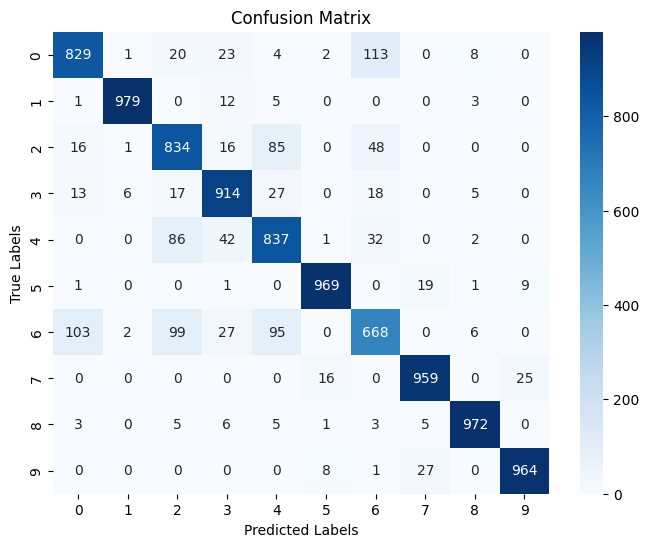

Accuracy:  0.8925  Loss:  0.31887614477722565  Macro F1:  0.8918733141874255


(np.float64(0.31887614477722565), 0.8925, np.float64(0.8918733141874255))

In [37]:
with open(filename, 'rb') as file:
    loaded_model = pickle.load(file)

eval.predict(loaded_model, x_test, y_test, cm=True)


# Final Model

Epoch 1/10: 100%|██████████| 375/375 [00:17<00:00, 21.29it/s]


Epoch:  1
Train
Accuracy:  0.8675  Loss:  0.4961520764649733  Macro F1:  0.8684044965822716
Val
Accuracy:  0.8583333333333333  Loss:  0.513858985759591  Macro F1:  0.8596542152562044


Epoch 2/10: 100%|██████████| 375/375 [00:15<00:00, 24.31it/s]


Epoch:  2
Train
Accuracy:  0.886  Loss:  0.3890295462110609  Macro F1:  0.8865181394768357
Val
Accuracy:  0.87475  Loss:  0.41903530370840003  Macro F1:  0.8757454852395148


Epoch 3/10: 100%|██████████| 375/375 [00:16<00:00, 22.70it/s]


...

Epoch:  8
Train
Accuracy:  0.9219166666666667  Loss:  0.23506013907183507  Macro F1:  0.921361564550384
Val
Accuracy:  0.8850833333333333  Loss:  0.328212550243106  Macro F1:  0.884143685636474


Epoch 9/10: 100%|██████████| 375/375 [00:14<00:00, 25.61it/s]


Epoch:  9
Train
Accuracy:  0.9281458333333333  Loss:  0.21590580615287658  Macro F1:  0.9266995438644413
Val
Accuracy:  0.8896666666666667  Loss:  0.32219804456932044  Macro F1:  0.887493242547659


Epoch 10/10: 100%|██████████| 375/375 [00:15<00:00, 23.95it/s]


Epoch:  10
Train
Accuracy:  0.9370208333333333  Loss:  0.19336239795248902  Macro F1:  0.9367425449160786
Val
Accuracy:  0.89475  Loss:  0.30342864529428415  Macro F1:  0.8944645934179812


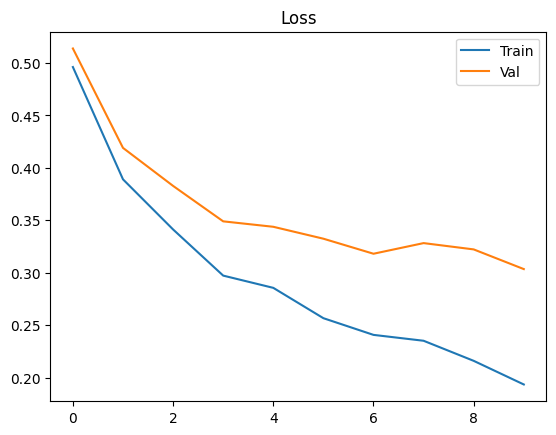

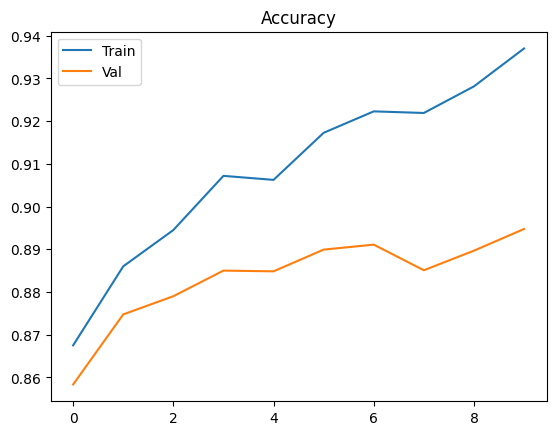

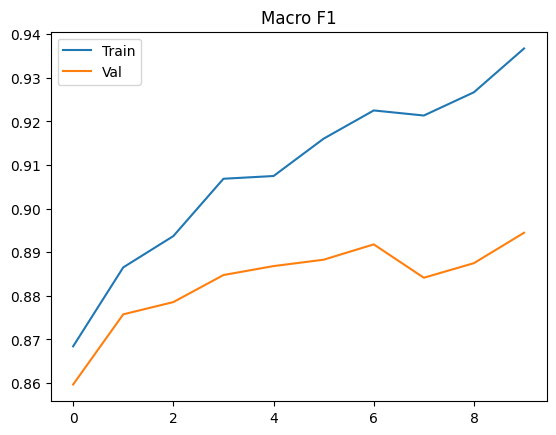

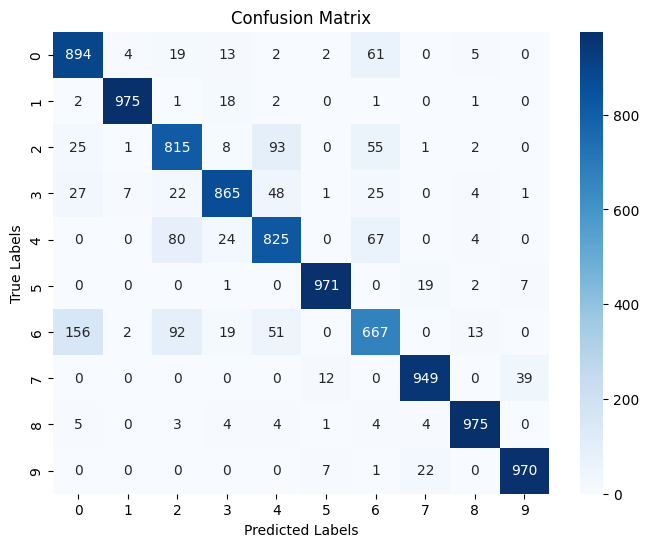

Accuracy:  0.8906  Loss:  0.32545484273006137  Macro F1:  0.8899843668893658


(np.float64(0.32545484273006137), 0.8906, np.float64(0.8899843668893658))

In [38]:
model=FNN().MODEL2(alpha=0.1/128,decay=0.9999,itr=1,dropout=0.2)

eval=Evaluation()
model1=eval.trainRan(model, 10, 128, x_trn, y_trn, x_val, y_val) 
eval.predict(model1, x_test, y_test, cm=True)  